# Which cell type sits next to which

Every mined rule is one dot on a grid: the **center cell** on the y axis, the
**neighbor cell** on the x axis. The dot's color says how strong the rule is
(lift by default), its size says the second number - confidence inside a single
FOV, or how much of a group has the rule when the grids are aggregated.

Negative rules are kept as well (`KIND = None`), so a blue dot reads as
*these two avoid each other* on the same scale a red dot reads as *these two sit
together*. The cell types are in the same fixed order in every grid, so any two
grids line up square by square.

Three sections, all of them called per organ x stage: one grid per FOV, one per
patient, and one per organ x stage.


## Configuration & Constants
Change these, then re-run any section below. A dot is always colored by **lift**; its
size is **confidence** in a single-FOV grid and **how much of the group has the rule**
in the aggregated ones.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))      # shared helpers, one level up

# Plotting helpers live next to this notebook
from cell_pair_grid_vis import (CELL_GROUP_ORDER, plot_rule_matrix,
                                plot_rule_matrix_panel)

# Shared loader + rule-name cleaning (also used by the other two summary notebooks)
import data_helper as dh
from data_helper import check_rule_overlap


In [2]:
# ==========================================
# CONFIGURATION & CONSTANTS
# ==========================================
# Which rules may become dots
RULE_MAX_ITEMS = 2          # a grid holds one cell type per side, so 2 = pairwise
NO_SELF        = True       # drop rules where a cell type repeats (Muscle -> Muscle)
KIND           = None       # 'attracts', 'avoids', or None for every rule

# What a dot shows. Kept fixed for now: the color always means lift, and the size
# always means confidence (a single FOV) or the share of the group (aggregated).
COLOR_BY = 'Lift'
SIZE_BY  = 'Confidence'

# Which FOVs take part, and how they are grouped
SCORE_COLUMN = 'Pathological score'          # or 'Clinical score'
STAGE_ORDER  = ['Control_S', 'Control', 'Mild', 'Severe']
ORGAN_ORDER  = ['Colon', 'Duodenum']
UNIT_COL     = 'FOV'        # what a share counts: 'FOV', 'Biopsy' or 'PatientID'
MIN_SHARE    = 0.1          # an aggregated grid keeps a pair only above this share

# Which mining run: data_helper.RESULT_CSV_PATH, shared by every notebook.
# To read a different one, pass its path to dh.load_results / rs.load below.
# Panel layout
PANEL_COLS = 3
MAX_PANELS = 12             # a panel never draws more grids than this


## Load Data
The same loader and the same rule table as `result_summary_pair_analysis.ipynb` and
`result_summary_rule_space.ipynb`, so all three notebooks describe the same rules.


In [3]:
# Load cells, FOVs and biopsies (shared loader, see data_helper.py).
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()


Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


In [4]:
# Load the mined rules. KIND = None keeps the avoiding rules too.
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS,
                             kind=KIND)


Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9719 rules (max_items=2, kind=None).


## Helper methods
Plain data work only - nothing is drawn here. Everything that draws lives in
`vis_helper.py`, under *Rule matrix*.


In [5]:
def pair_rules(df_results, no_self=NO_SELF):
    """One row per rule per FOV, with the single center and neighbor cell type.

    Only a rule with exactly one cell type on each side can sit on a grid.
    """
    ants = df_results['Antecedents'].apply(ast.literal_eval)
    cons = df_results['Consequents'].apply(ast.literal_eval)
    keep = (ants.apply(len) == 1) & (cons.apply(len) == 1)
    if no_self:
        keep &= ~pd.Series([check_rule_overlap(a, c) for a, c in zip(ants, cons)],
                           index=df_results.index)

    pairs = df_results[keep].copy()
    pairs['antecedent'] = ants[keep].str[0].str.replace('_CENTER', '', regex=False)
    pairs['consequent'] = cons[keep].str[0].str.replace('_NEIGHBOR', '', regex=False)
    return pairs

PAIRS = pair_rules(df_results)
print(f"{len(PAIRS)} rule rows on the grid "
      f"(no_self={NO_SELF}, kind={KIND}), "
      f"{PAIRS['FOV'].nunique()} FOVs.")


8761 rule rows on the grid (no_self=True, kind=None), 288 FOVs.


In [6]:
# Plain words for the groups the cells come in.
GROUP_NAMES = {'Epithel': 'epithelial', 'Immune': 'immune', 'Stroma': 'structure'}

def cell_groups(df_cells):
    """{cell type: group}, from the 'population' column of the cell table."""
    known = df_cells[['cell type', 'population']].drop_duplicates('cell type')
    return {str(ct): GROUP_NAMES.get(str(pop), 'other')
            for ct, pop in zip(known['cell type'], known['population'])}

def cell_order(pairs, groups):
    """The fixed axis order: by group, then A-Z inside the group.

    Every grid in this notebook gets this same list, which is what makes two grids
    comparable square by square.
    """
    present = set(pairs['antecedent']) | set(pairs['consequent'])
    rank = {g: i for i, g in enumerate(CELL_GROUP_ORDER)}
    return sorted(present, key=lambda c: (rank.get(groups.get(c, 'other'), 9), c))

CELL_GROUPS = cell_groups(df_cells)
CELL_ORDER = cell_order(PAIRS, CELL_GROUPS)
print(f"{len(CELL_ORDER)} cell types on the axes:")
for group in CELL_GROUP_ORDER:
    names = [c for c in CELL_ORDER if CELL_GROUPS.get(c, 'other') == group]
    print(f"  {group:<11} {', '.join(names)}")


32 cell types on the axes:
  epithelial  Endocrine, Epithelial, Goblet, Neuroendocrine, Paneth
  immune      APC, Bcell, CD3T, CD4T, CD8T, DC, ImmuneOther, ImmuneOther_CD45RA, Macrophage, Macrophage_Calp, Mast, Monocyte, NK, Neutrophil, Neutrophil_CD15, Plasma, Plasma_CD38, Treg
  structure   Endothelial, Fibroblast, FibroticEpithelial, Mesenchymal_VIM, Neuron, SMV
  other       BrunnerGland, Muscle, Unidentified


In [7]:
METRIC_COLS = ['Lift', 'Conviction', 'Confidence', 'Support', 'Leverage']
RATIO_COLS = ['Lift', 'Conviction']     # ratios around 1 - averaged in log space
UNIT_NAMES = {'FOV': 'FOVs', 'Biopsy': 'biopsies', 'PatientID': 'patients'}


def share_note(unit_col=UNIT_COL, min_share=MIN_SHARE):
    """The piece of a subtitle naming the cut - empty when no pair is dropped."""
    return (f"  |  only pairs in >{min_share:.0%} of the {UNIT_NAMES[unit_col]}"
            if min_share else "")

def scope(organs=None, stages=None, score_col=SCORE_COLUMN):
    """The FOVs of this organ / stage, and the rule rows that came from them."""
    fovs = df_fovs.copy()
    if organs is not None:
        fovs = fovs[fovs['Organ'].isin(organs)]
    if stages is not None:
        fovs = fovs[fovs[score_col].isin(stages)]
    # A FOV where no rule was mined is not part of the group: it would shrink every
    # share, and it would draw as a blank grid in the panels below.
    fovs = fovs[fovs['FOV'].isin(PAIRS['FOV'])]
    return PAIRS[PAIRS['FOV'].isin(fovs['FOV'])].copy(), fovs

def aggregate(rows, fovs, unit_col=UNIT_COL, min_share=MIN_SHARE, where=None):
    """One row per cell-type pair, for a whole group of FOVs.

    Every metric is the **mean over the FOVs where the rule fired** - the FOVs
    without it are not counted as zero, they are counted in `share` instead:
    the part of the group's units (FOVs, biopsies or patients) that has the rule.

    Lift and conviction are ratios around 1, so they are averaged **in log space**
    (the geometric mean). Otherwise one FOV with a lift of 40 would pull the whole
    group's dot red, even if every other FOV sat near 1.

    A pair in `min_share` or less of the group's units is dropped, so a crowded grid
    can be cut down to the pairs most of the group has. How many went is printed
    under `where`, the name of the group being drawn.
    Returns (table, how many units the group has).
    """
    total = fovs[unit_col].nunique()
    cols = [c for c in METRIC_COLS if c in rows.columns]
    if rows.empty or not total:
        return pd.DataFrame(columns=['antecedent', 'consequent', 'share'] + cols), total

    rows = rows.assign(unit=rows['FOV'].map(dict(zip(fovs['FOV'], fovs[unit_col]))))
    ratios = [c for c in cols if c in RATIO_COLS]
    rows[ratios] = np.log(rows[ratios].where(rows[ratios] > 0))

    grouped = rows.groupby(['antecedent', 'consequent'])
    table = grouped[cols].mean()
    table[ratios] = np.exp(table[ratios])          # back into the metric's own units
    table['share'] = grouped['unit'].nunique() / total
    if min_share:
        keep = table['share'] > min_share
        print(f"{where or 'group'}: {len(table) - keep.sum()} of {len(table)} pairs "
              f"dropped, in {min_share:.0%} or less of the "
              f"{UNIT_NAMES[unit_col]} ({total})")
        table = table[keep]
    return table.reset_index(), total


In [8]:
def where_from(fovs, score_col):
    """The organ and the stage these FOVs belong to, for a title."""
    organs = ', '.join(sorted(fovs['Organ'].dropna().unique()))
    stages = ', '.join(sorted(fovs[score_col].dropna().unique()))
    return f"{organs} - {stages}"

def show_fov(fov, score_col=SCORE_COLUMN, save=None):
    """One FOV on its own - the readable version of a square in the panel below."""
    meta = df_fovs[df_fovs['FOV'] == fov]
    plot_rule_matrix(
        PAIRS[PAIRS['FOV'] == fov], CELL_ORDER, CELL_GROUPS,
        color_col=COLOR_BY, size_col=SIZE_BY, size_label=SIZE_BY.lower(), save=save,
        title=f"FOV {fov}",
        subtitle=f"{where_from(meta, score_col)}  |  color = lift, size = confidence")

def show_patient(patient, patient_col='PatientID', score_col=SCORE_COLUMN, save=None):
    """One patient on its own, over every FOV that patient has."""
    own = df_fovs[(df_fovs[patient_col] == patient) & df_fovs['FOV'].isin(PAIRS['FOV'])]
    table, total = aggregate(PAIRS[PAIRS['FOV'].isin(own['FOV'])], own, unit_col='FOV',
                             where=f'patient {patient}')
    plot_rule_matrix(
        table, CELL_ORDER, CELL_GROUPS, color_col=COLOR_BY, size_col='share',
        size_label="share of the\npatient's FOVs", save=save,
        title=f"patient {patient}",
        subtitle=f"{where_from(own, score_col)}  |  n={total} FOVs"
                 + share_note('FOV')
                 + "  |  color = mean lift, size = share of the patient's FOVs")

def show_group(organ, stage, score_col=SCORE_COLUMN, unit_col=UNIT_COL, save=None):
    """One organ x stage on its own."""
    rows, fovs = scope([organ], [stage], score_col)
    table, total = aggregate(rows, fovs, unit_col=unit_col,
                             where=f'{organ} - {stage}')
    plot_rule_matrix(
        table, CELL_ORDER, CELL_GROUPS, color_col=COLOR_BY, size_col='share',
        size_label=f"share of the\ngroup's {UNIT_NAMES[unit_col]}", save=save,
        title=f"{organ} - {stage}",
        subtitle=f"stage from: {score_col}  |  n={total} {UNIT_NAMES[unit_col]}"
                 + share_note(unit_col)
                 + f"  |  color = mean lift, size = share of the {UNIT_NAMES[unit_col]}")


In [9]:
def show_fov_matrices(organ, stage, score_col=SCORE_COLUMN, max_panels=MAX_PANELS, save=None):
    """One grid per FOV of this organ x stage, all of them on one shared scale."""
    rows, fovs = scope([organ], [stage], score_col)
    names = sorted(fovs['FOV'])[:max_panels]
    left_out = fovs['FOV'].nunique() - len(names)
    frames = {fov: rows[rows['FOV'] == fov] for fov in names}

    plot_rule_matrix_panel(
        frames, CELL_ORDER, CELL_GROUPS, color_col=COLOR_BY, size_col=SIZE_BY,
        num_cols=PANEL_COLS, size_label=SIZE_BY.lower(), save=save,
        title=f"{organ} - {stage}: which cell type sits next to which, one grid per FOV",
        subtitle=f"stage from: {score_col}  |  {len(names)} FOVs"
                 + (f" ({left_out} more not drawn)" if left_out else "")
                 + "  |  color = lift, size = confidence")

def show_patient_matrices(organ, stage, score_col=SCORE_COLUMN, patient_col='PatientID',
                          max_panels=MAX_PANELS, save=None):
    """One grid per patient of this organ x stage.

    Color = the mean over that patient's FOVs where the rule fired;
    dot size = the share of that patient's FOVs that have it.
    """
    rows, fovs = scope([organ], [stage], score_col)
    patients = sorted(fovs[patient_col].dropna().unique())[:max_panels]
    left_out = fovs[patient_col].nunique() - len(patients)

    frames = {}
    for patient in patients:
        own = fovs[fovs[patient_col] == patient]
        table, total = aggregate(rows[rows['FOV'].isin(own['FOV'])], own, unit_col='FOV',
                                 where=f'patient {patient}')
        frames[f"{patient}  (n={total} FOVs)"] = table

    plot_rule_matrix_panel(
        frames, CELL_ORDER, CELL_GROUPS, color_col=COLOR_BY, size_col='share',
        size_ref=1.0, num_cols=PANEL_COLS, size_label="share of the\npatient's FOVs",
        save=save,
        title=f"{organ} - {stage}: which cell type sits next to which, one grid per patient",
        subtitle=f"stage from: {score_col}  |  {len(patients)} patients"
                 + (f" ({left_out} more not drawn)" if left_out else "")
                 + share_note('FOV')
                 + "  |  color = mean lift, size = share of the patient's FOVs")

def show_group_matrices(organs=ORGAN_ORDER, stages=STAGE_ORDER, score_col=SCORE_COLUMN,
                        unit_col=UNIT_COL, save=None):
    """One grid per organ x stage - the whole panel in one picture.

    Color = the mean over the FOVs where the rule fired; dot size = the share of the
    group's units (`unit_col`) that have it.
    """
    frames = {}
    for organ in organs:
        for stage in stages:
            rows, fovs = scope([organ], [stage], score_col)
            table, total = aggregate(rows, fovs, unit_col=unit_col,
                                     where=f'{organ} - {stage}')
            frames[f"{organ} - {stage}  (n={total} {UNIT_NAMES[unit_col]})"] = table

    plot_rule_matrix_panel(
        frames, CELL_ORDER, CELL_GROUPS, color_col=COLOR_BY, size_col='share',
        size_ref=1.0, num_cols=len(stages), save=save,
        size_label=f"share of the\ngroup's {UNIT_NAMES[unit_col]}",
        title="which cell type sits next to which, one grid per organ x stage",
        subtitle=f"stage from: {score_col}" + share_note(unit_col)
                 + f"  |  color = mean lift, "
                 + f"size = share of the group's {UNIT_NAMES[unit_col]}")


# 1. One grid per FOV
The raw picture, nothing averaged: every dot is one rule mined in that one FOV.
Color = lift, size = confidence. Start with a single FOV, which is drawn large enough
to read; the panel then puts many FOVs of one organ x stage on one shared scale.


In [10]:
# The FOVs to choose from, for this organ x stage.
_, fovs_here = scope(['Duodenum'], ['Severe'])
print(sorted(fovs_here['FOV'])[:12])


['GVHD_02_FOV_1_R', 'GVHD_02_FOV_2_R', 'GVHD_06_FOV_1', 'GVHD_06_FOV_2', 'GVHD_06_FOV_3', 'GVHD_06_FOV_4', 'GVHD_06_FOV_5', 'GVHD_08_FOV_1', 'GVHD_08_FOV_2', 'GVHD_08_FOV_3', 'GVHD_08_FOV_4', 'GVHD_09_FOV_1']


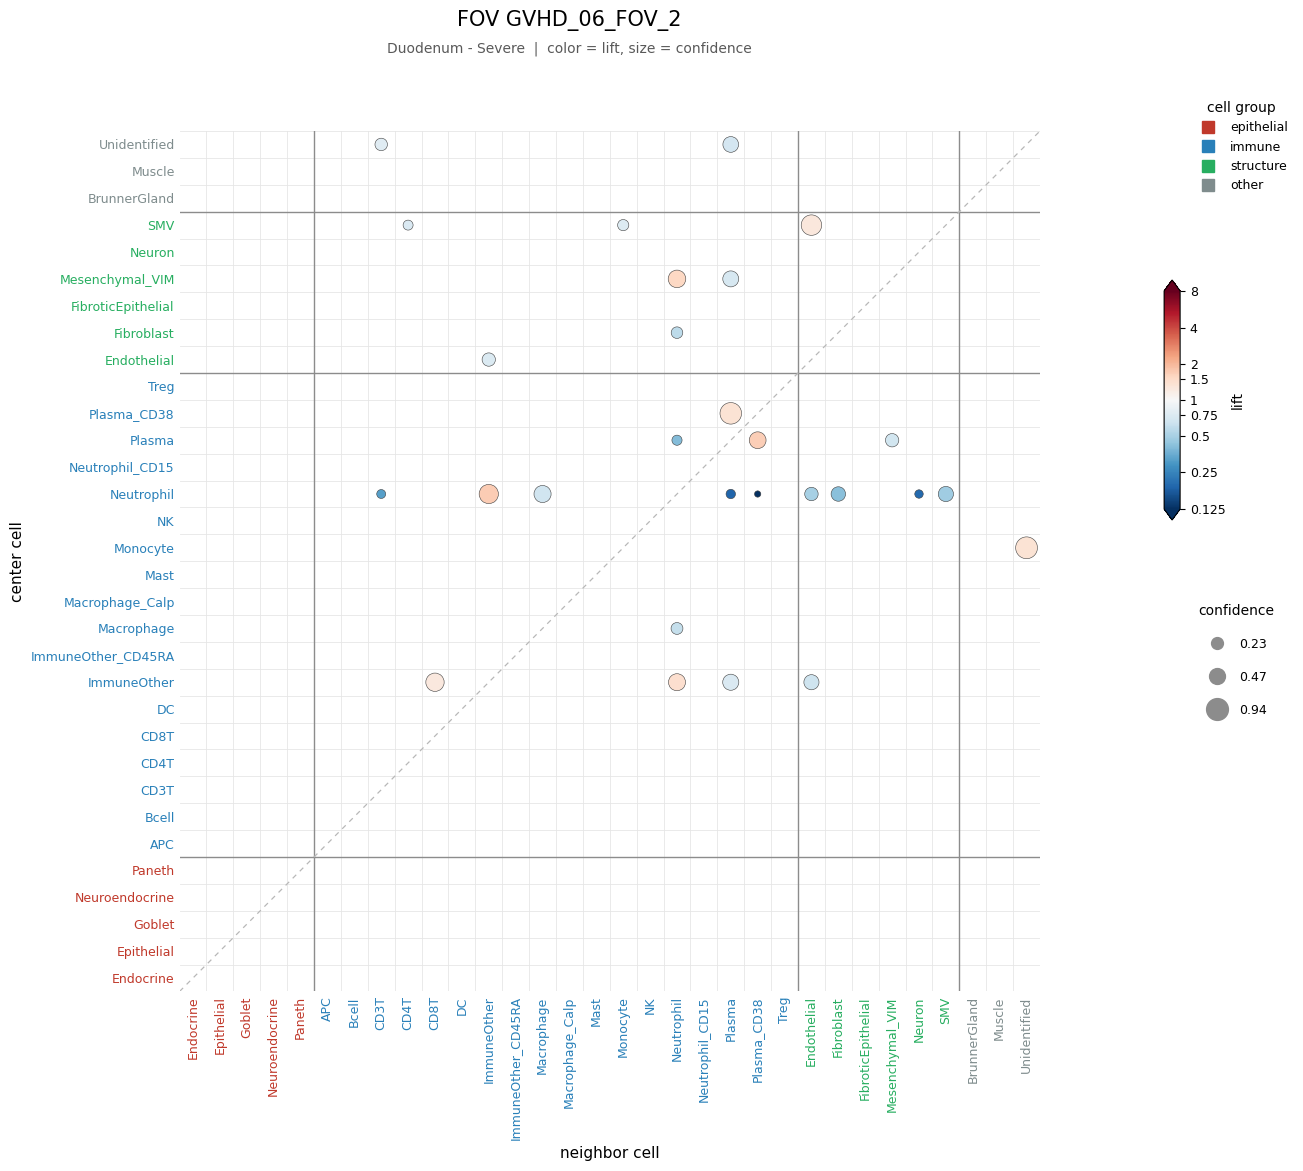

In [11]:
show_fov('GVHD_06_FOV_2')


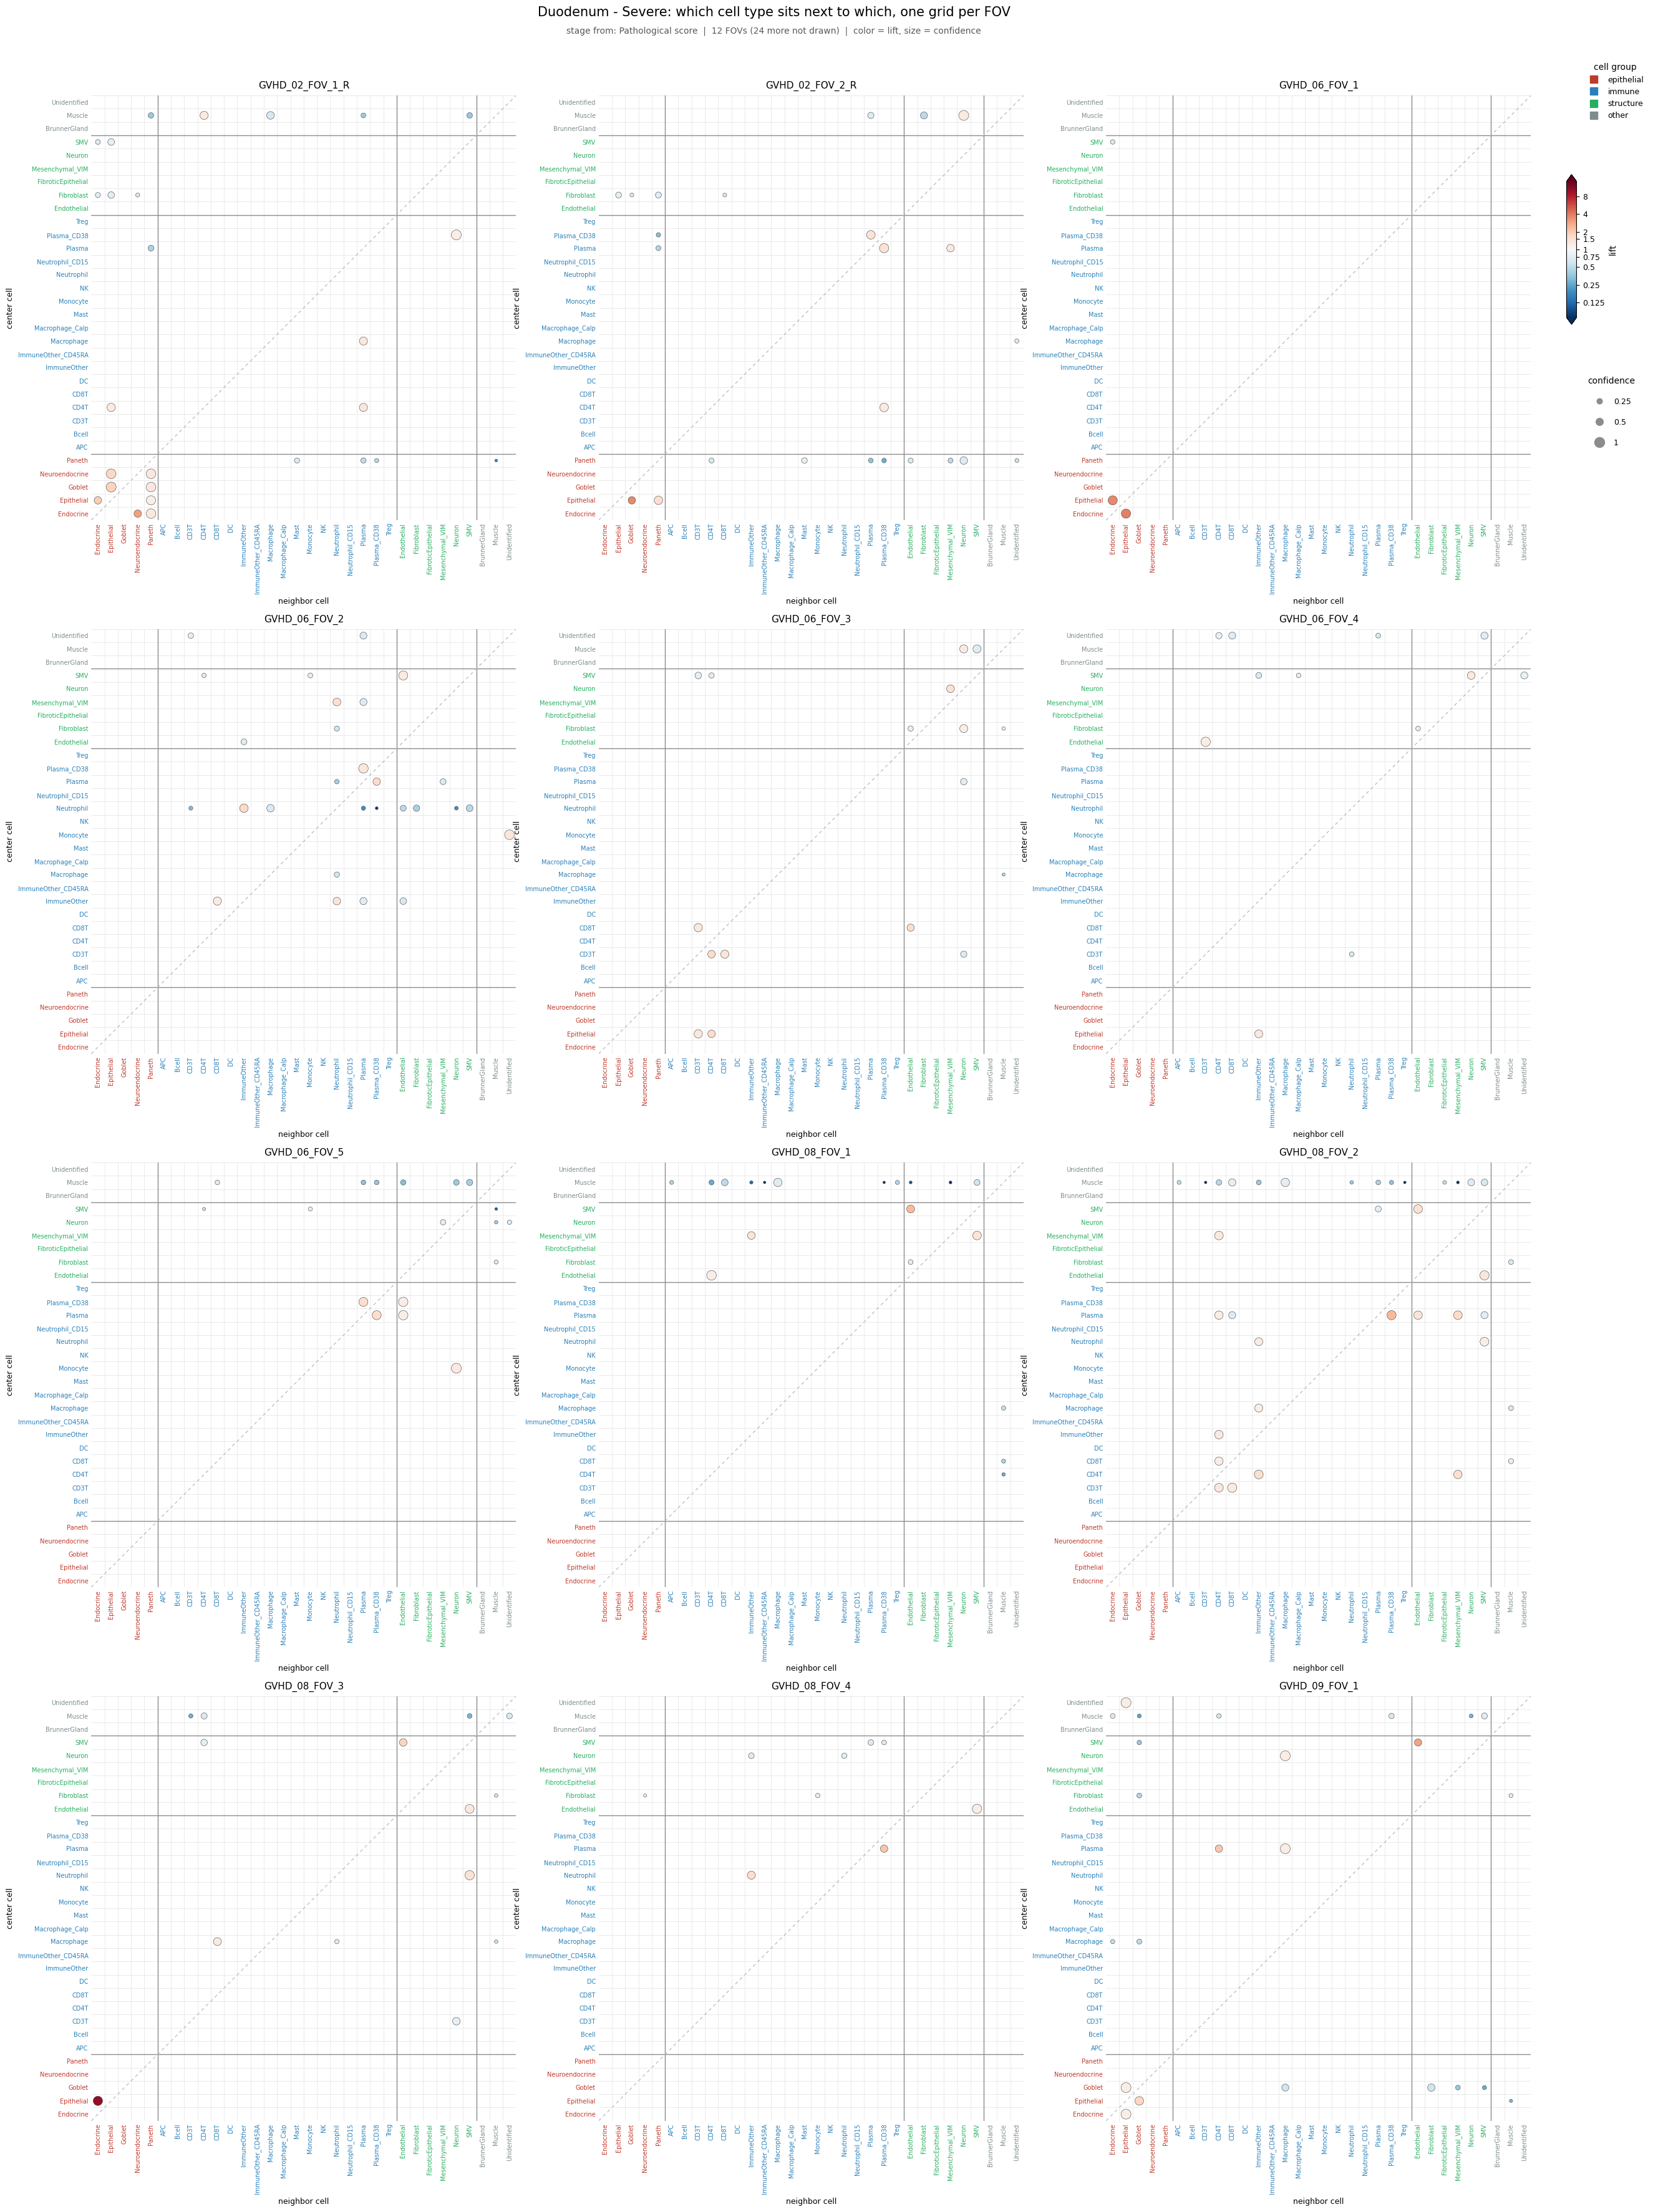

In [12]:
show_fov_matrices(organ='Duodenum', stage='Severe')


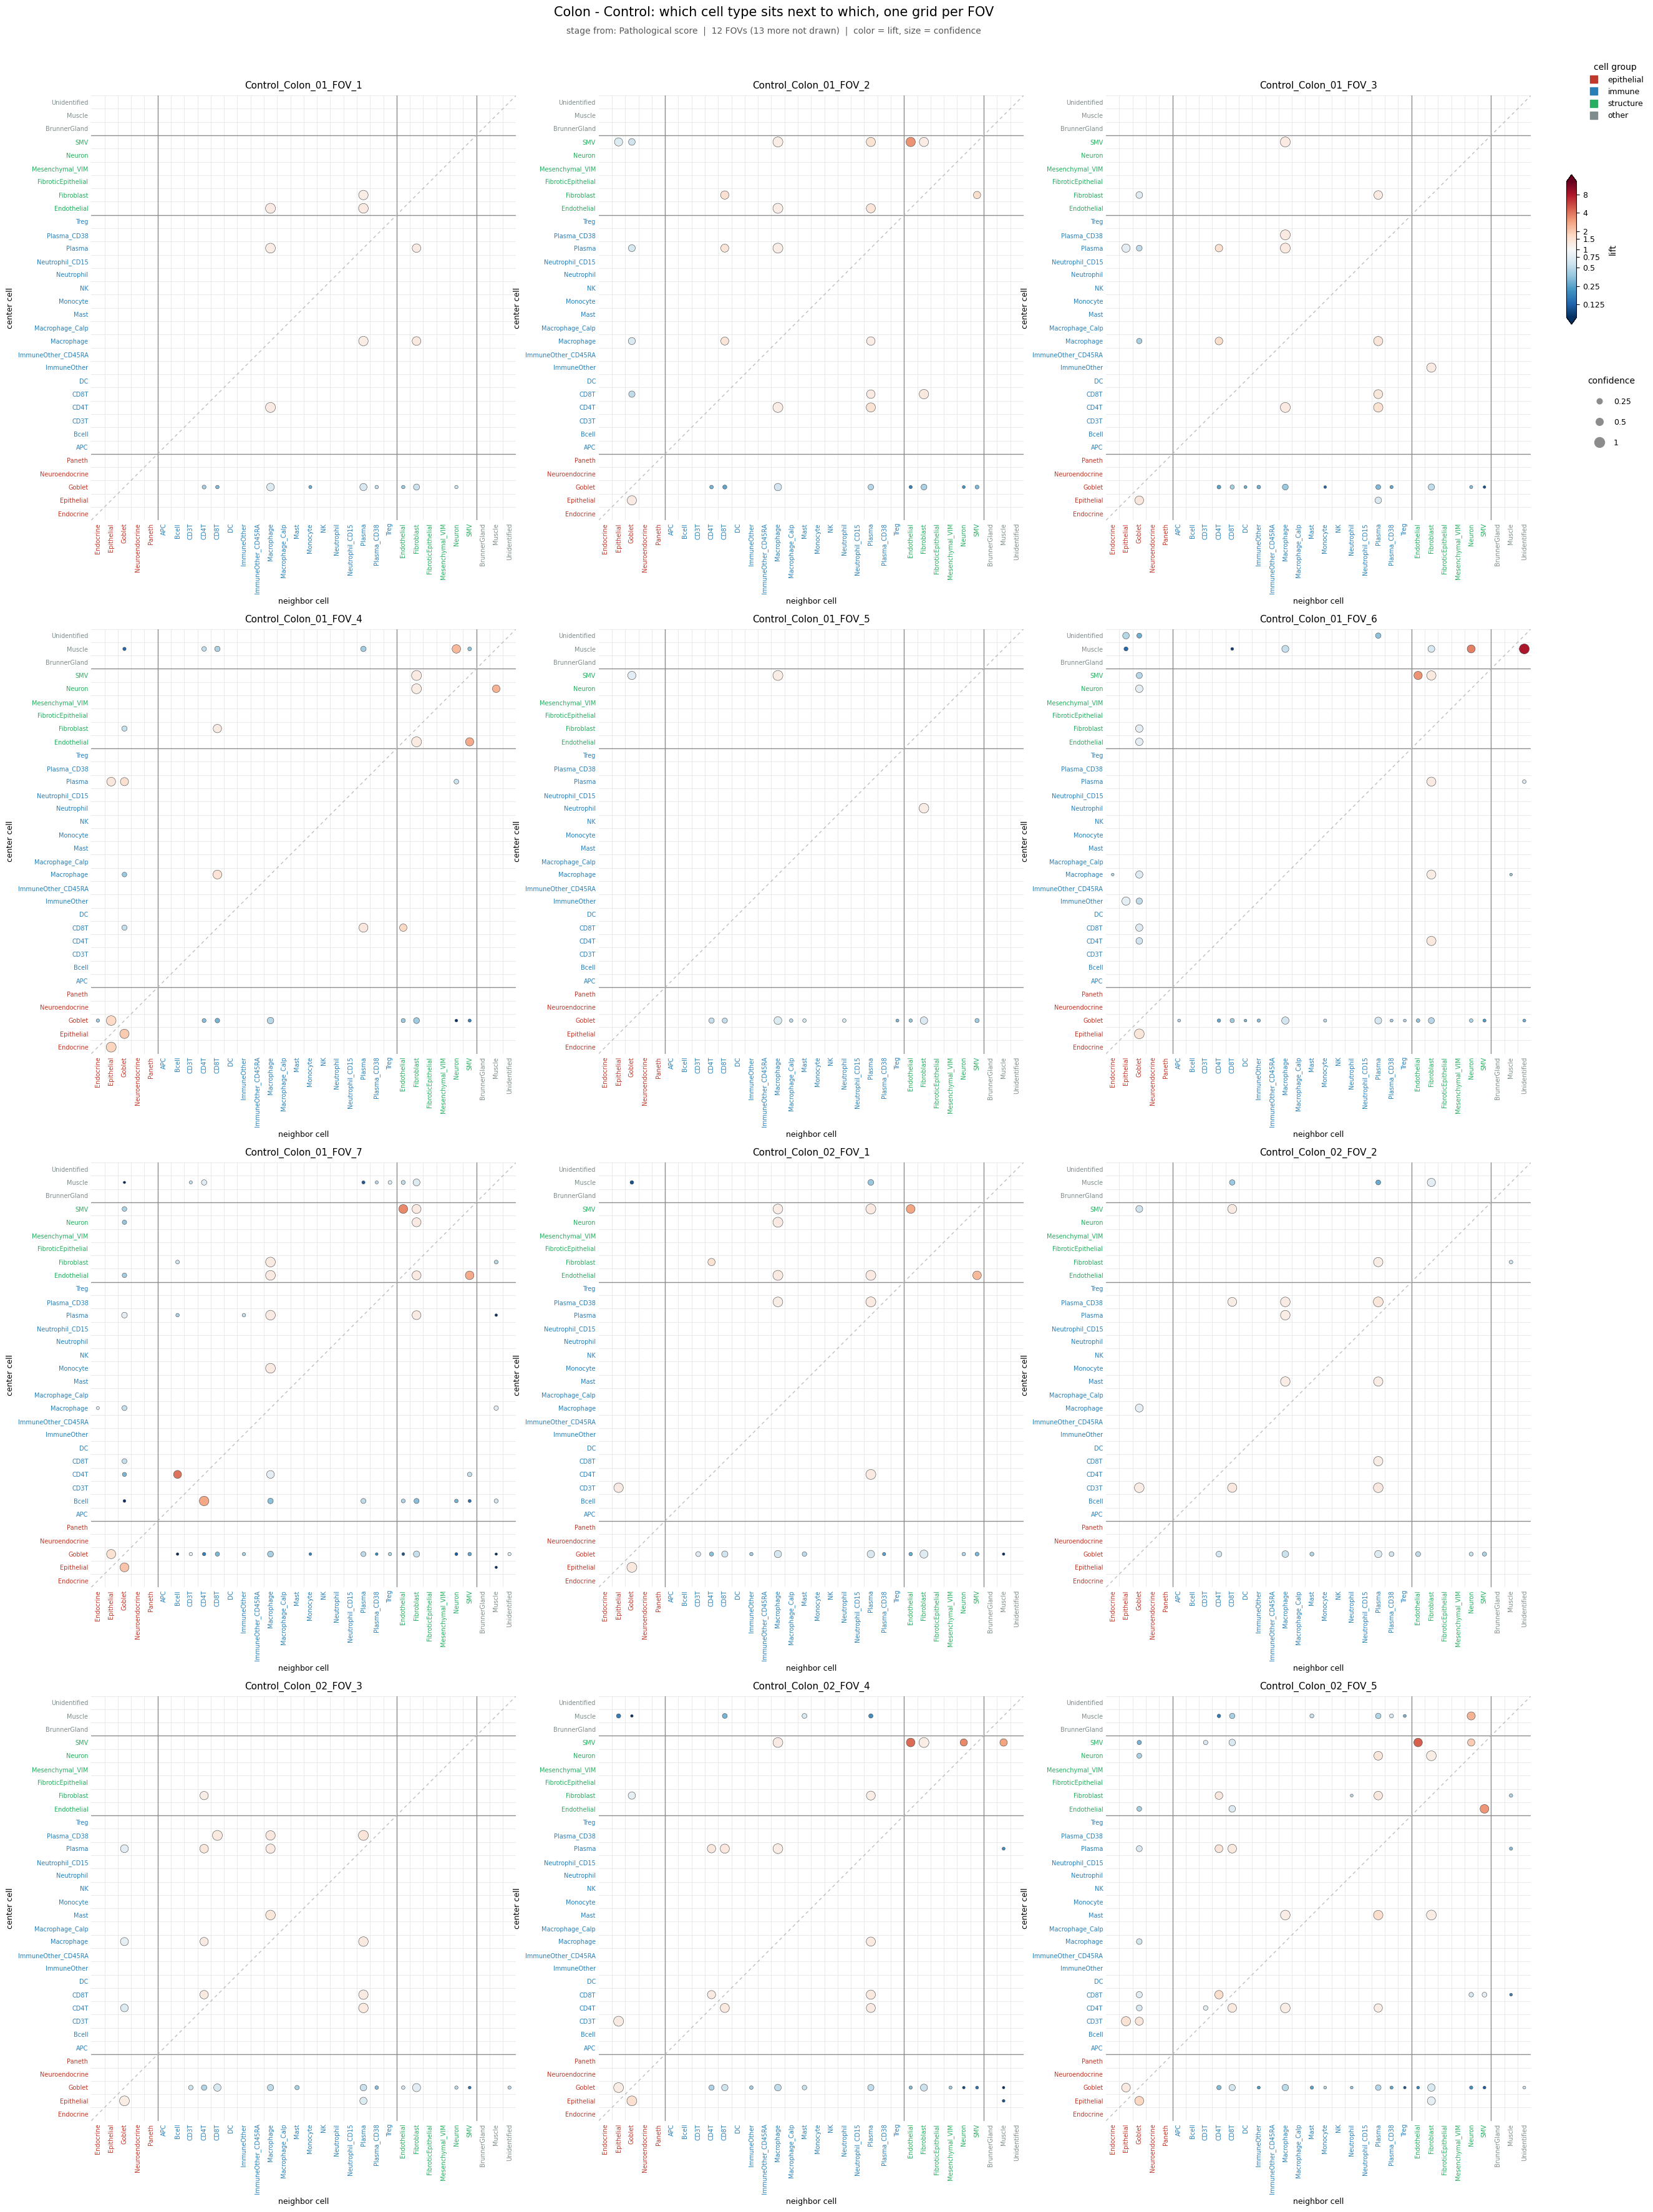

In [13]:
show_fov_matrices(organ='Colon', stage='Control')


# 2. One grid per patient
Now a grid is a whole patient. A dot's color is the mean lift over that patient's FOVs
**where the rule fired**, and its size is **how many of that patient's FOVs have it** -
so a big pale dot is a rule the patient has everywhere but weakly, and a small dark dot
is a strong rule seen in one FOV only. Each grid says how many FOVs the patient has.


patient Control_Colon_01: 0 of 110 pairs dropped, in 10% or less of the FOVs (7)


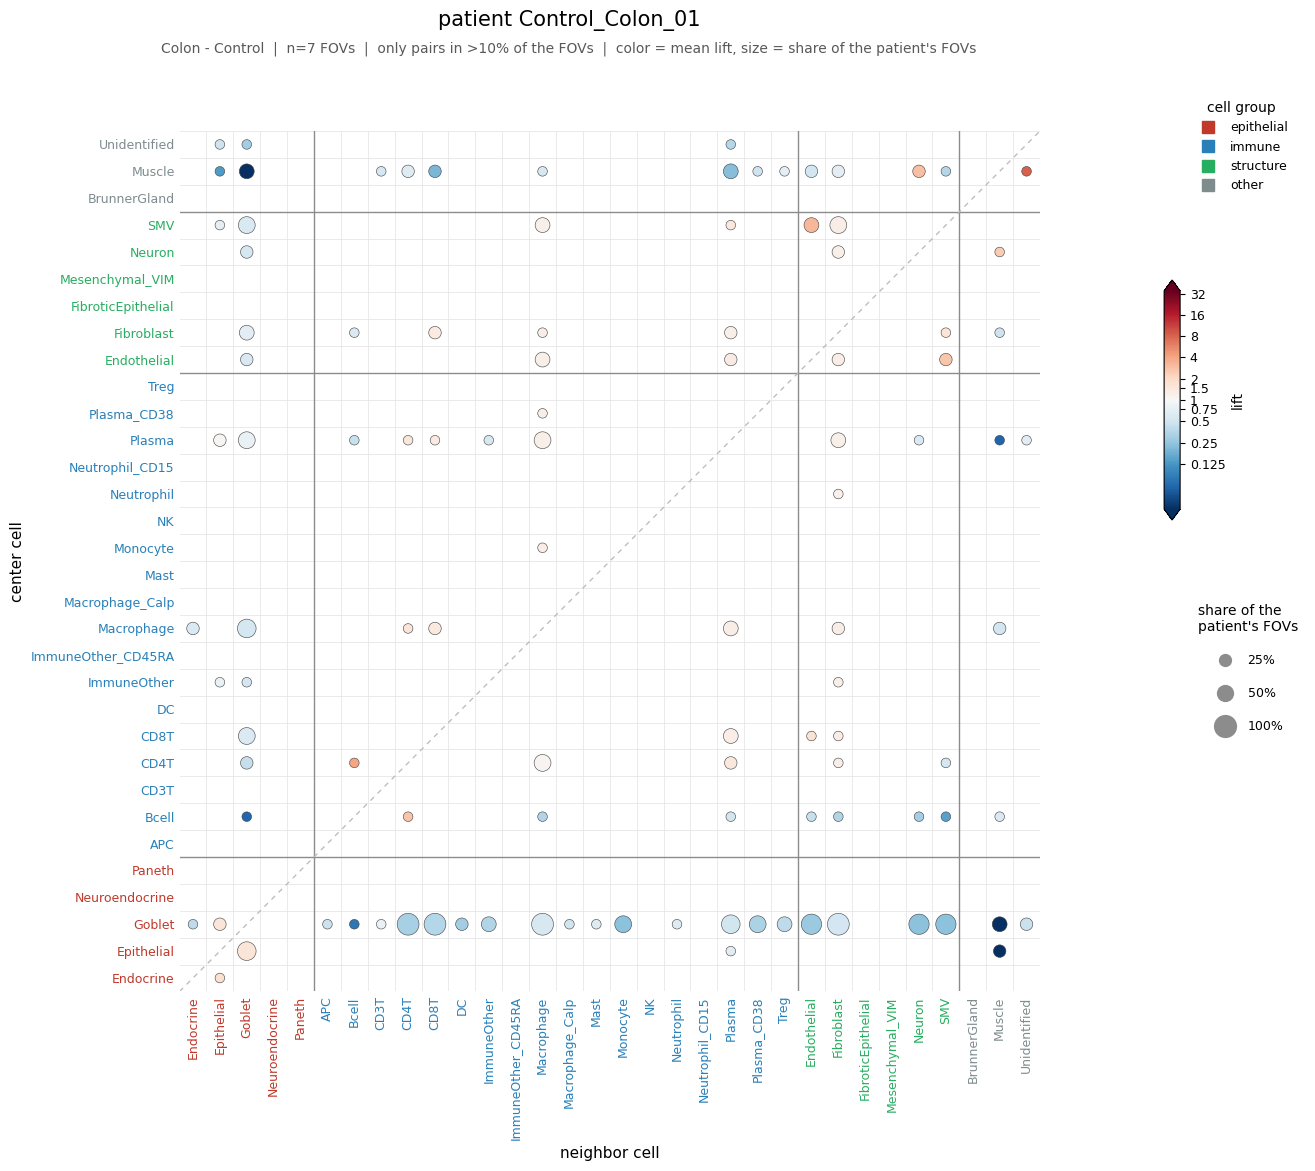

In [14]:
show_patient('Control_Colon_01')


patient Control_Colon_01: 0 of 110 pairs dropped, in 10% or less of the FOVs (7)
patient Control_Colon_02: 0 of 97 pairs dropped, in 10% or less of the FOVs (6)
patient Control_Colon_03: 0 of 85 pairs dropped, in 10% or less of the FOVs (6)
patient Control_Colon_04: 0 of 110 pairs dropped, in 10% or less of the FOVs (6)


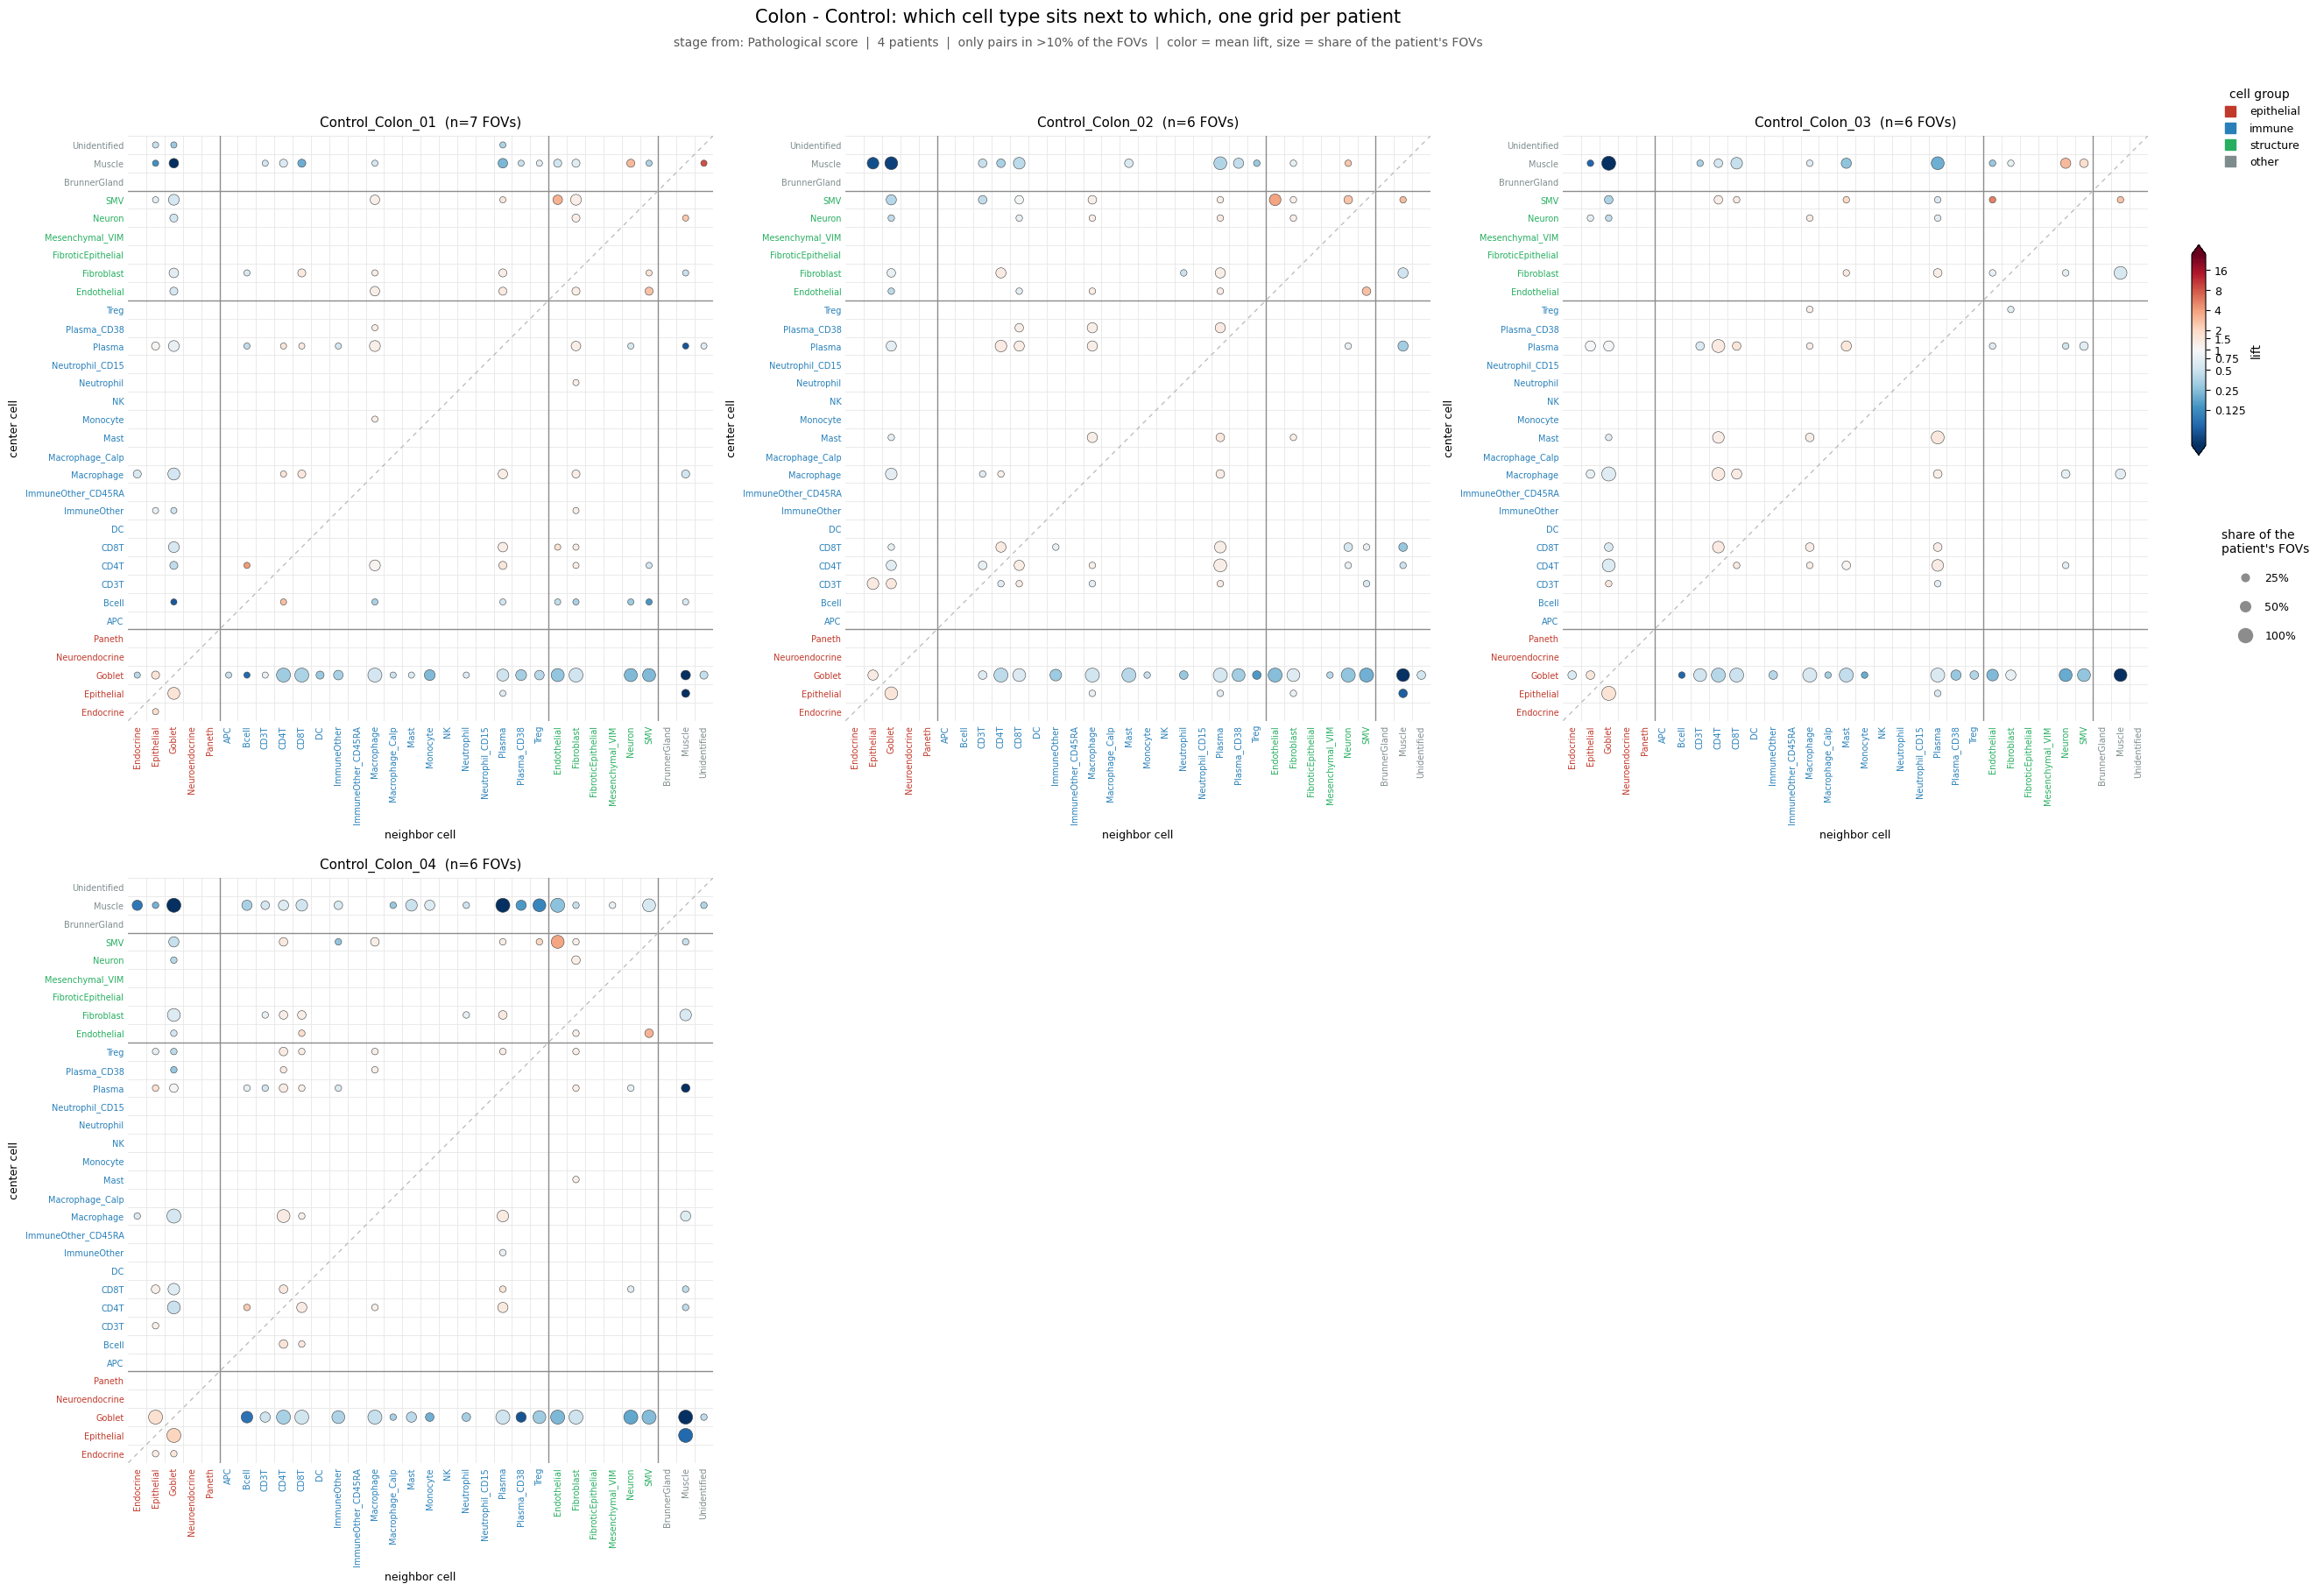

In [15]:
show_patient_matrices(organ='Colon', stage='Control')


patient P_02: 0 of 45 pairs dropped, in 10% or less of the FOVs (2)
patient P_06: 0 of 68 pairs dropped, in 10% or less of the FOVs (5)
patient P_08: 0 of 54 pairs dropped, in 10% or less of the FOVs (4)
patient P_09: 0 of 55 pairs dropped, in 10% or less of the FOVs (4)
patient P_11: 0 of 45 pairs dropped, in 10% or less of the FOVs (4)
patient P_14: 0 of 76 pairs dropped, in 10% or less of the FOVs (5)
patient P_23: 0 of 85 pairs dropped, in 10% or less of the FOVs (4)
patient P_25: 0 of 68 pairs dropped, in 10% or less of the FOVs (4)
patient P_54: 0 of 80 pairs dropped, in 10% or less of the FOVs (4)


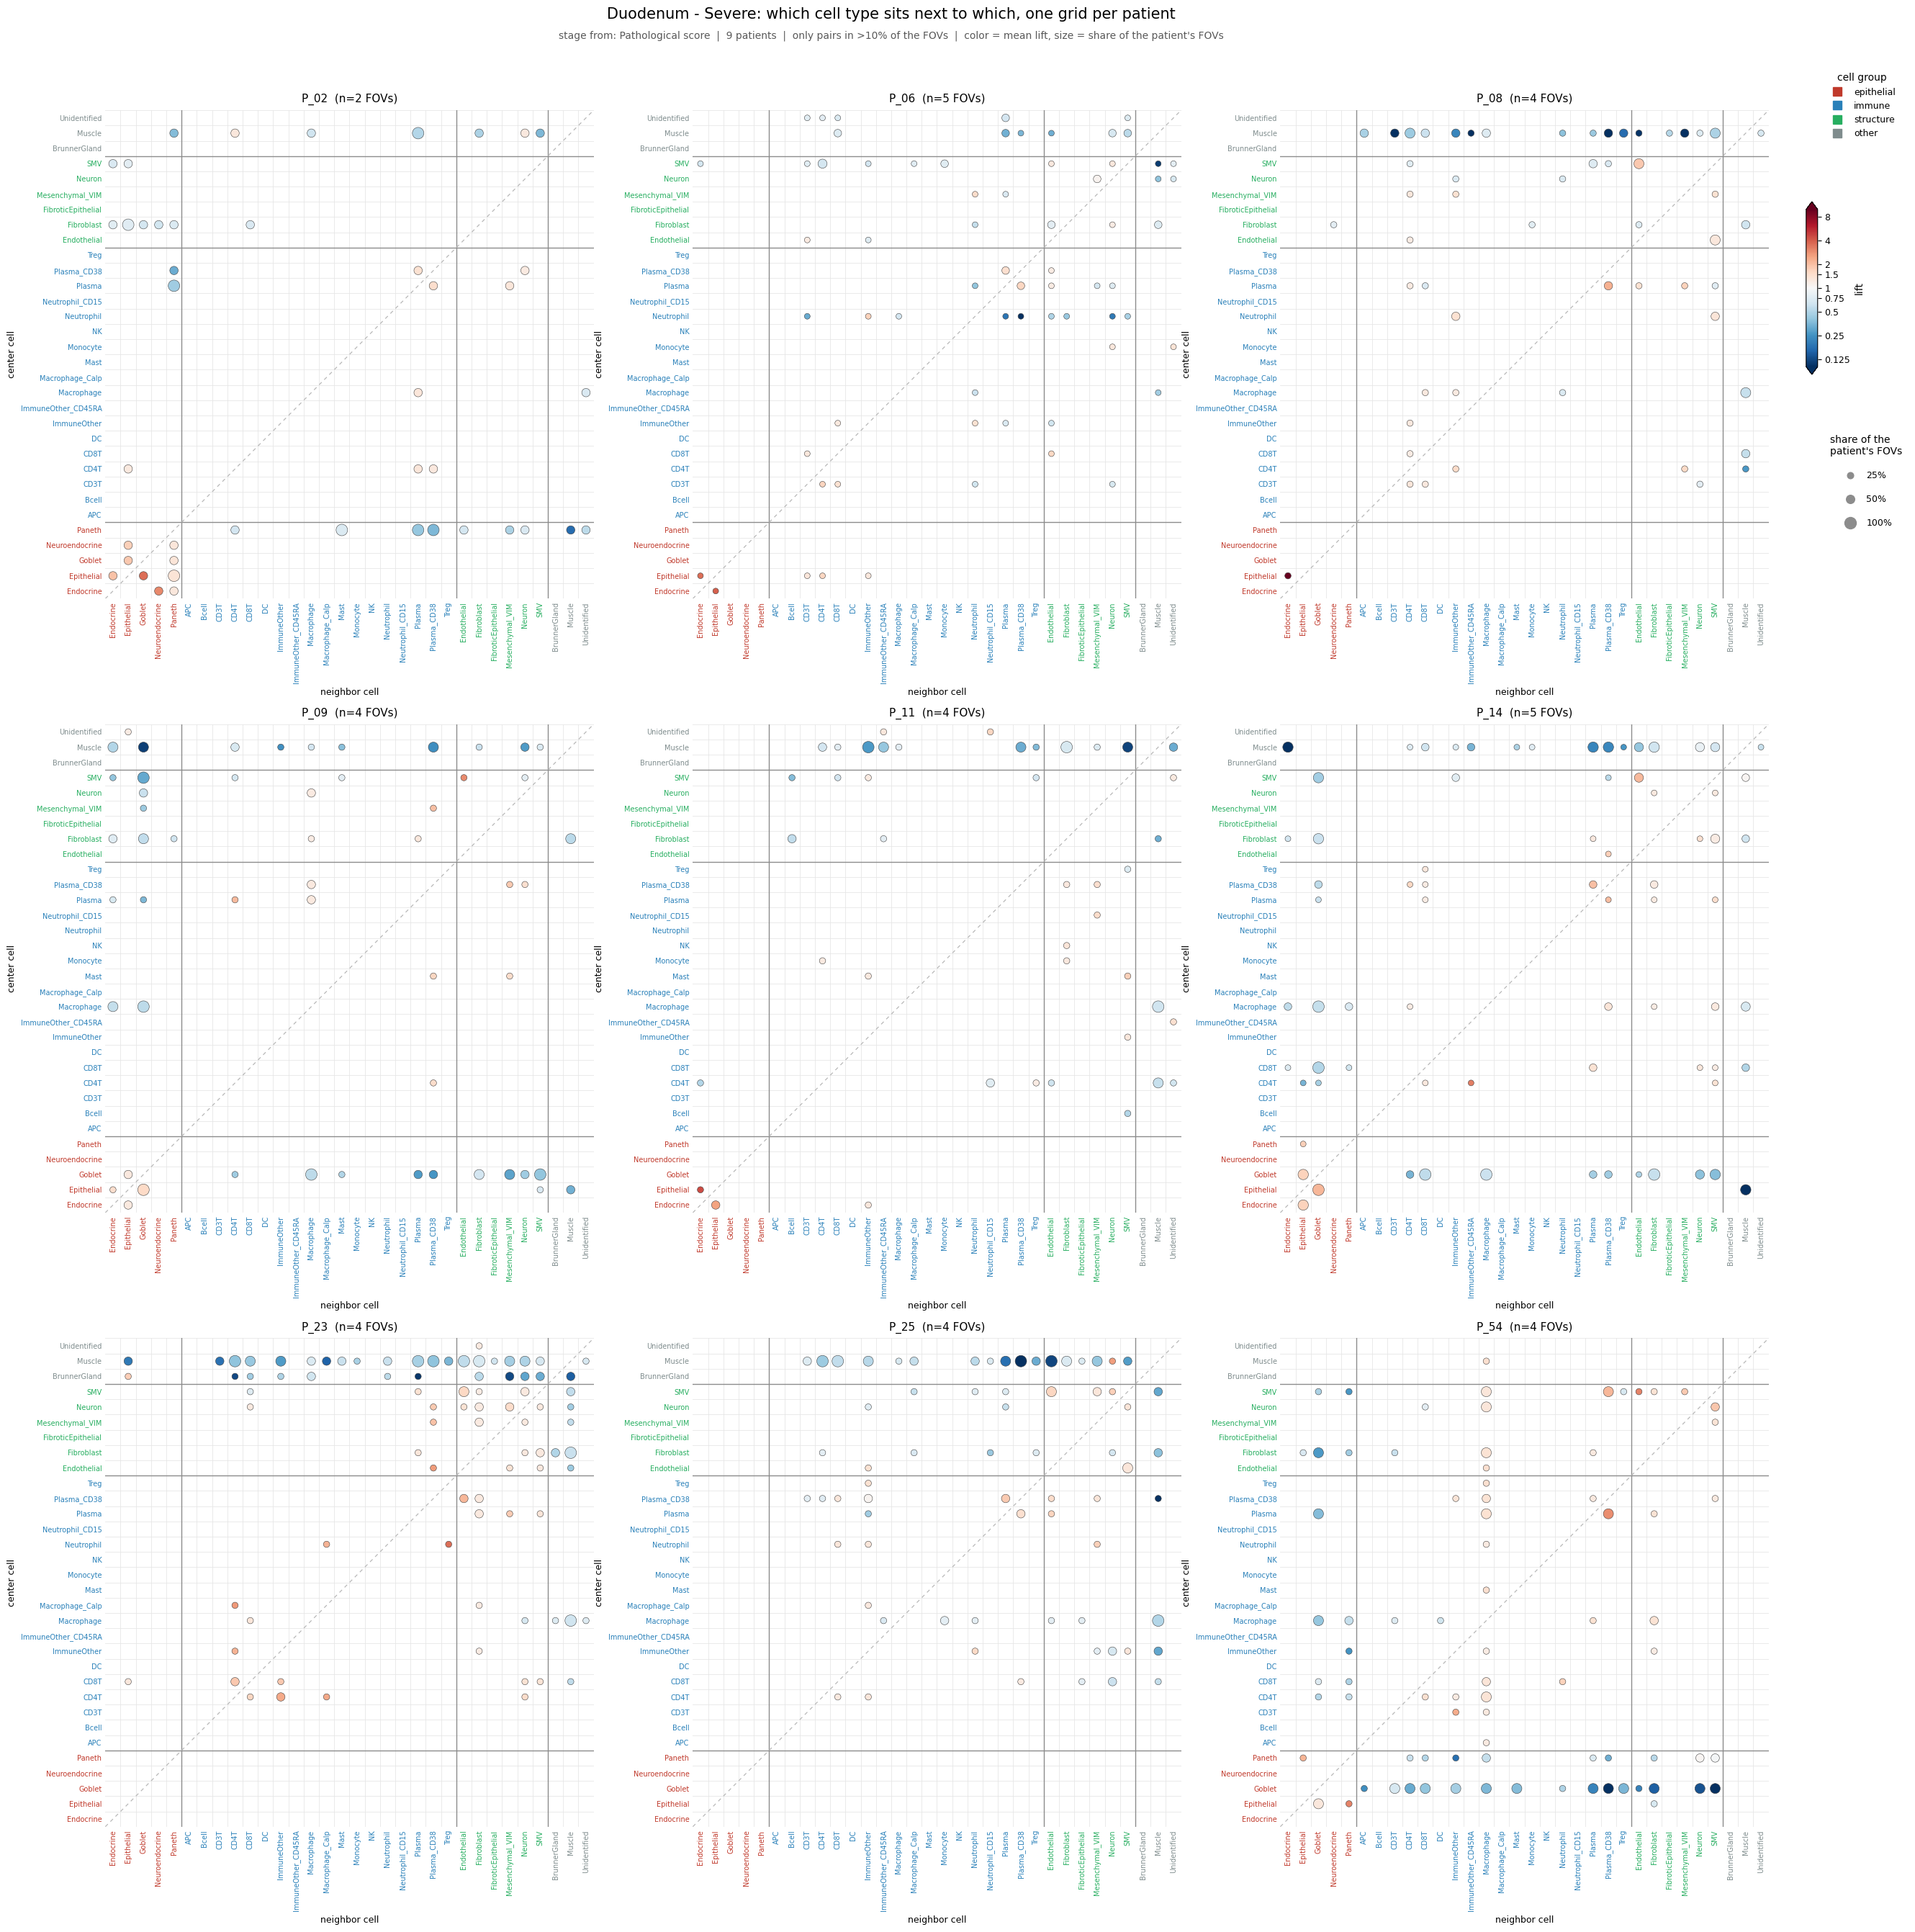

patient P_06: 0 of 68 pairs dropped, in 10% or less of the FOVs (5)
patient P_08: 0 of 54 pairs dropped, in 10% or less of the FOVs (4)
patient P_09: 0 of 55 pairs dropped, in 10% or less of the FOVs (4)
patient P_14: 0 of 76 pairs dropped, in 10% or less of the FOVs (5)
patient P_16: 0 of 77 pairs dropped, in 10% or less of the FOVs (3)
patient P_19: 0 of 118 pairs dropped, in 10% or less of the FOVs (4)
patient P_23: 0 of 85 pairs dropped, in 10% or less of the FOVs (4)
patient P_25: 0 of 68 pairs dropped, in 10% or less of the FOVs (4)
patient P_33: 0 of 60 pairs dropped, in 10% or less of the FOVs (2)
patient P_34: 0 of 29 pairs dropped, in 10% or less of the FOVs (2)
patient P_54: 0 of 80 pairs dropped, in 10% or less of the FOVs (4)


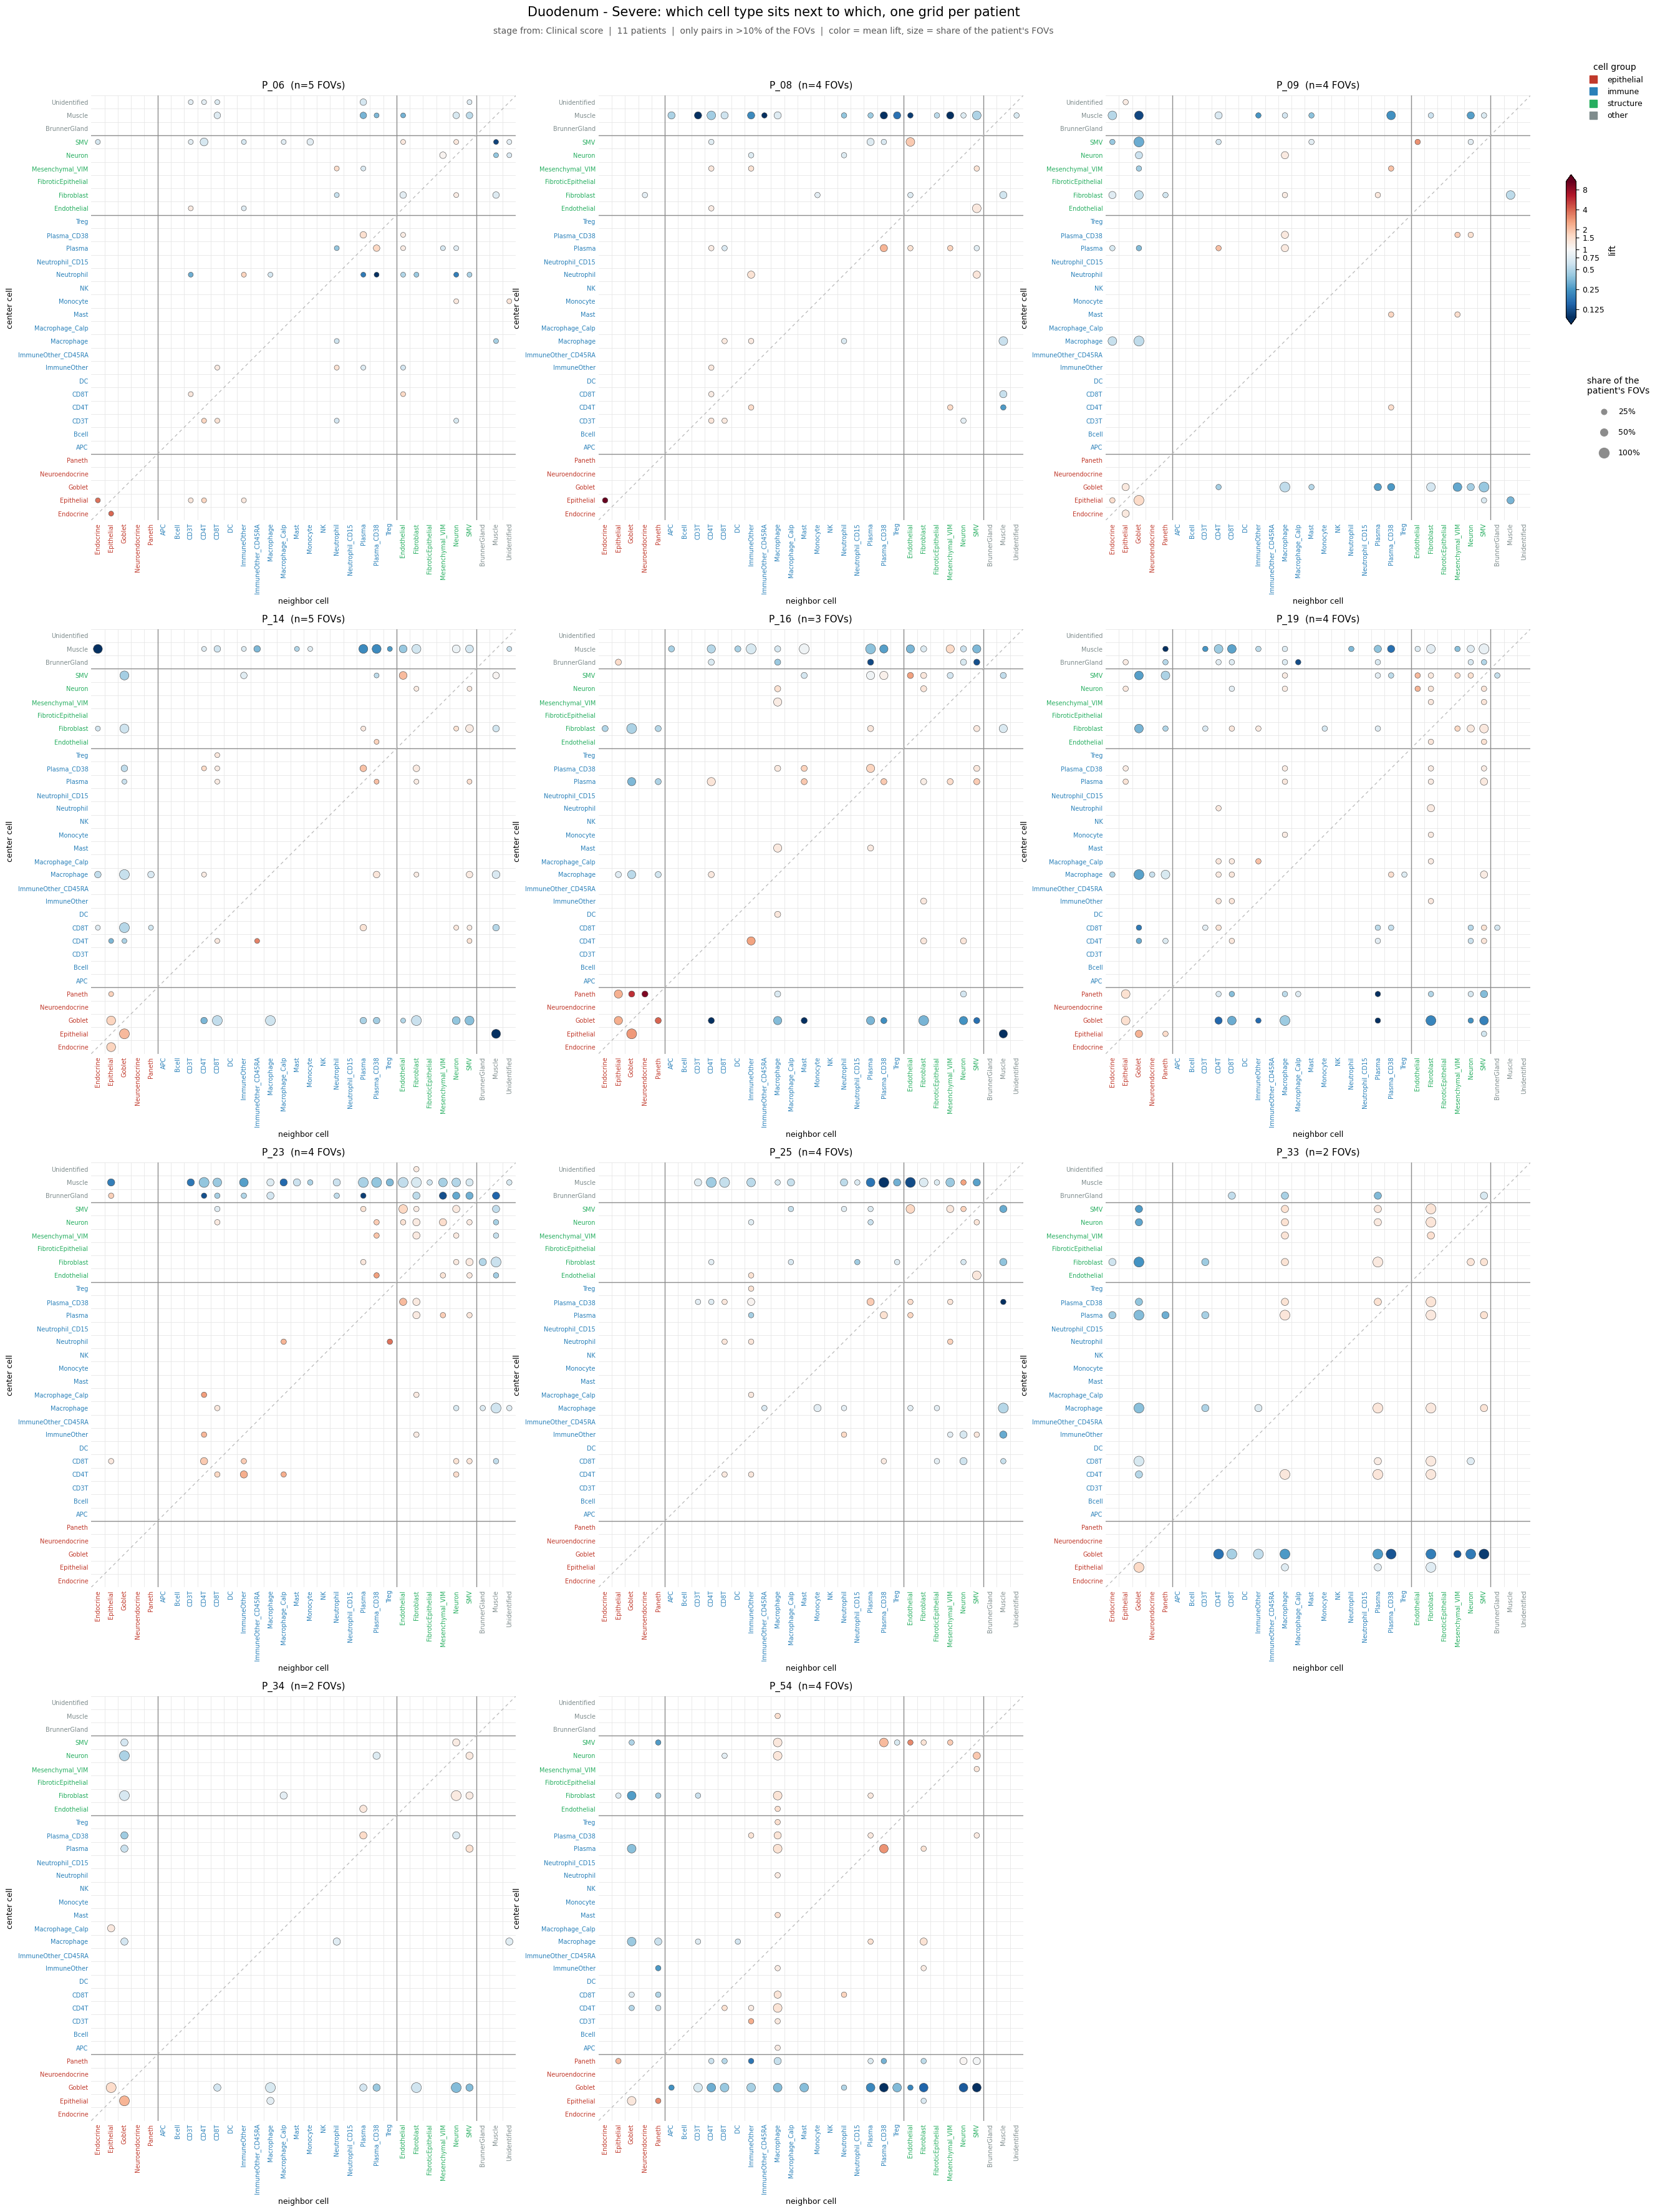

In [16]:
show_patient_matrices(organ='Duodenum', stage='Severe')

# The same patients, grouped by the clinical score instead of the pathological one.
show_patient_matrices(organ='Duodenum', stage='Severe', score_col='Clinical score')


# 3. One grid per organ x stage
The summary: the two organs across the four stages, in one picture on one scale.
Color = the mean lift over the FOVs where the rule fired, size = the share of the group
that has the rule. Reading down a column asks *does this pair behave the same in both
organs?*; reading across a row asks *does it change with the stage?*


Duodenum - Control: 147 of 196 pairs dropped, in 10% or less of the FOVs (31)


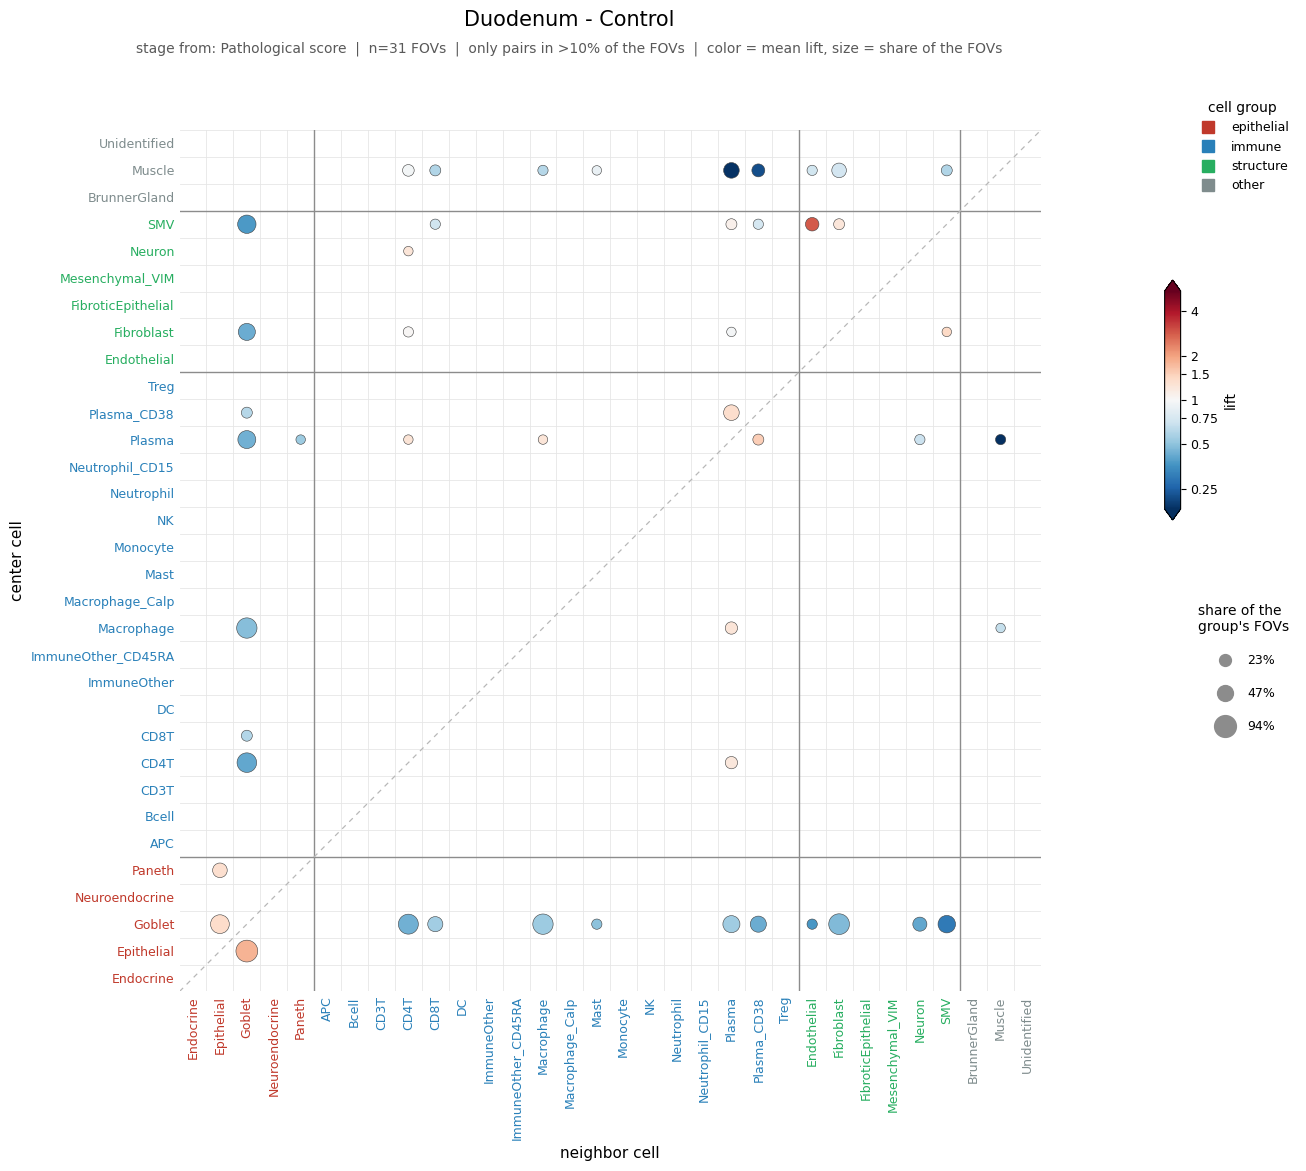

In [17]:
show_group('Duodenum', 'Control')


Duodenum - Mild: 298 of 382 pairs dropped, in 10% or less of the FOVs (103)


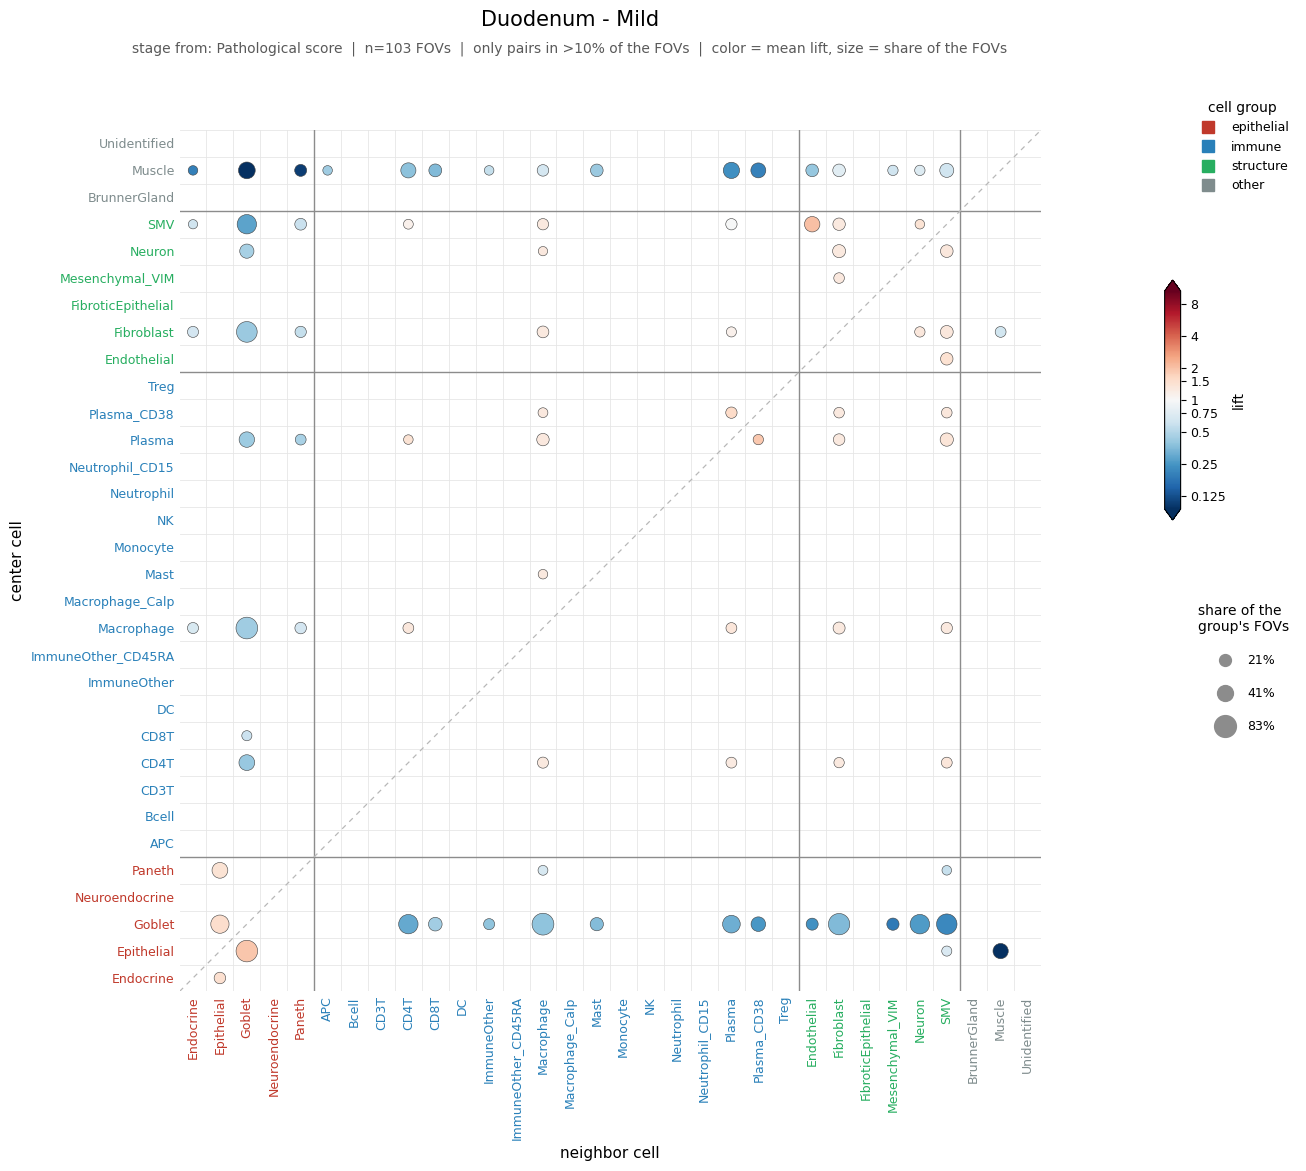

In [18]:
show_group('Duodenum', 'Mild')


Duodenum - Severe: 234 of 307 pairs dropped, in 10% or less of the FOVs (36)


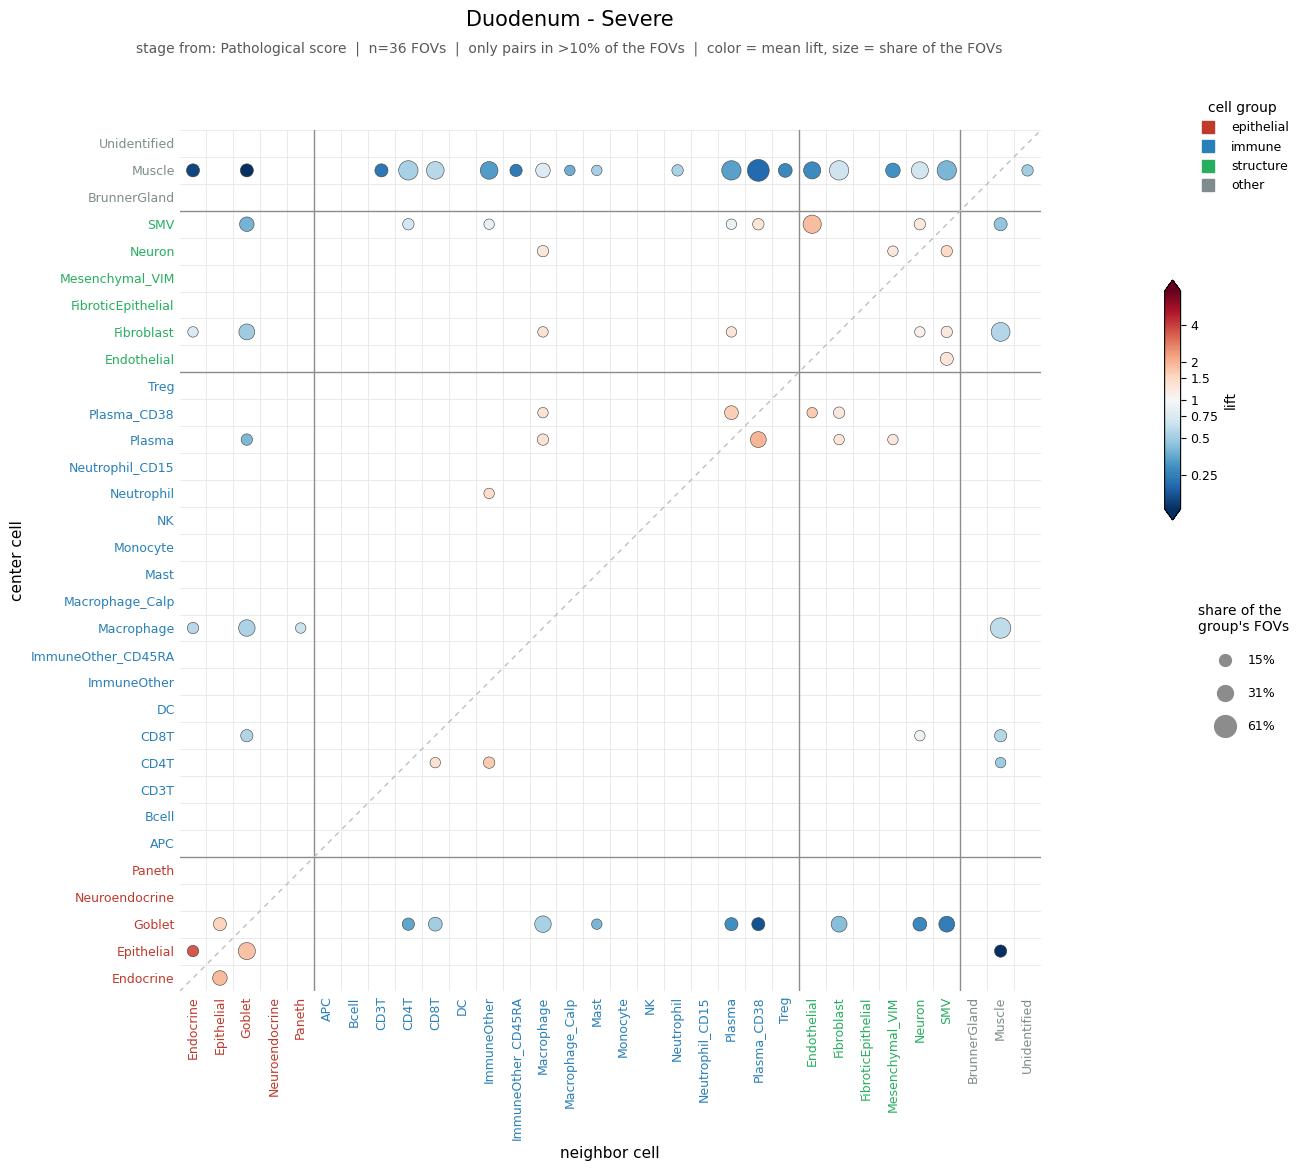

In [19]:
show_group('Duodenum', 'Severe')


Colon - Control: 90 of 183 pairs dropped, in 10% or less of the FOVs (25)


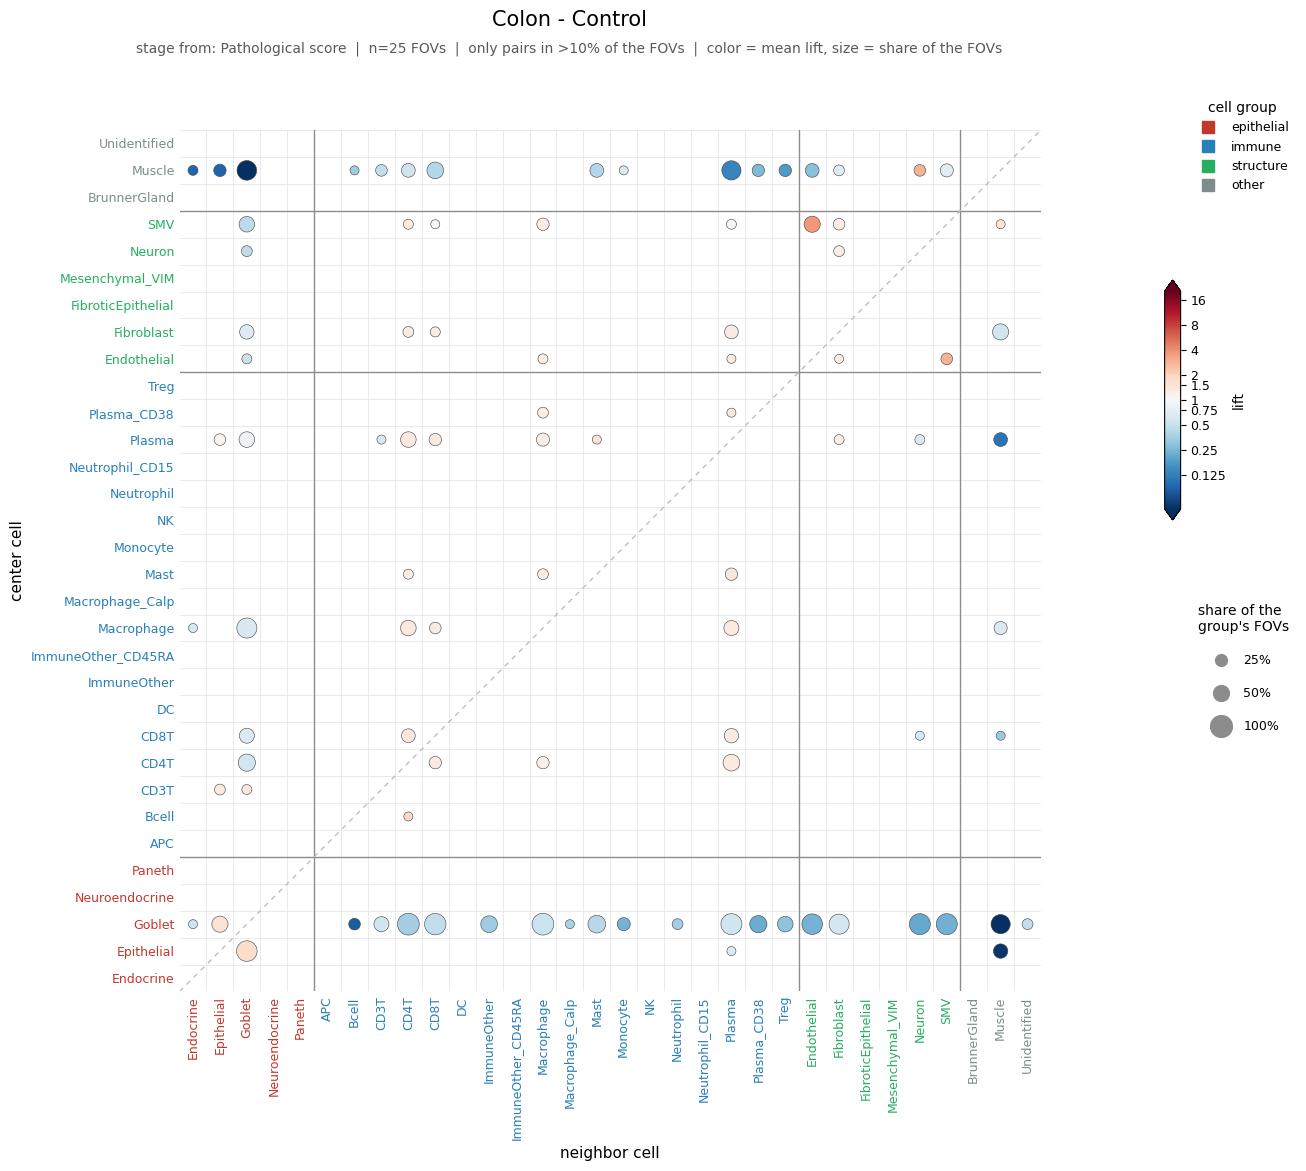

In [20]:
show_group('Colon', 'Control')


Colon - Mild: 136 of 196 pairs dropped, in 10% or less of the FOVs (40)


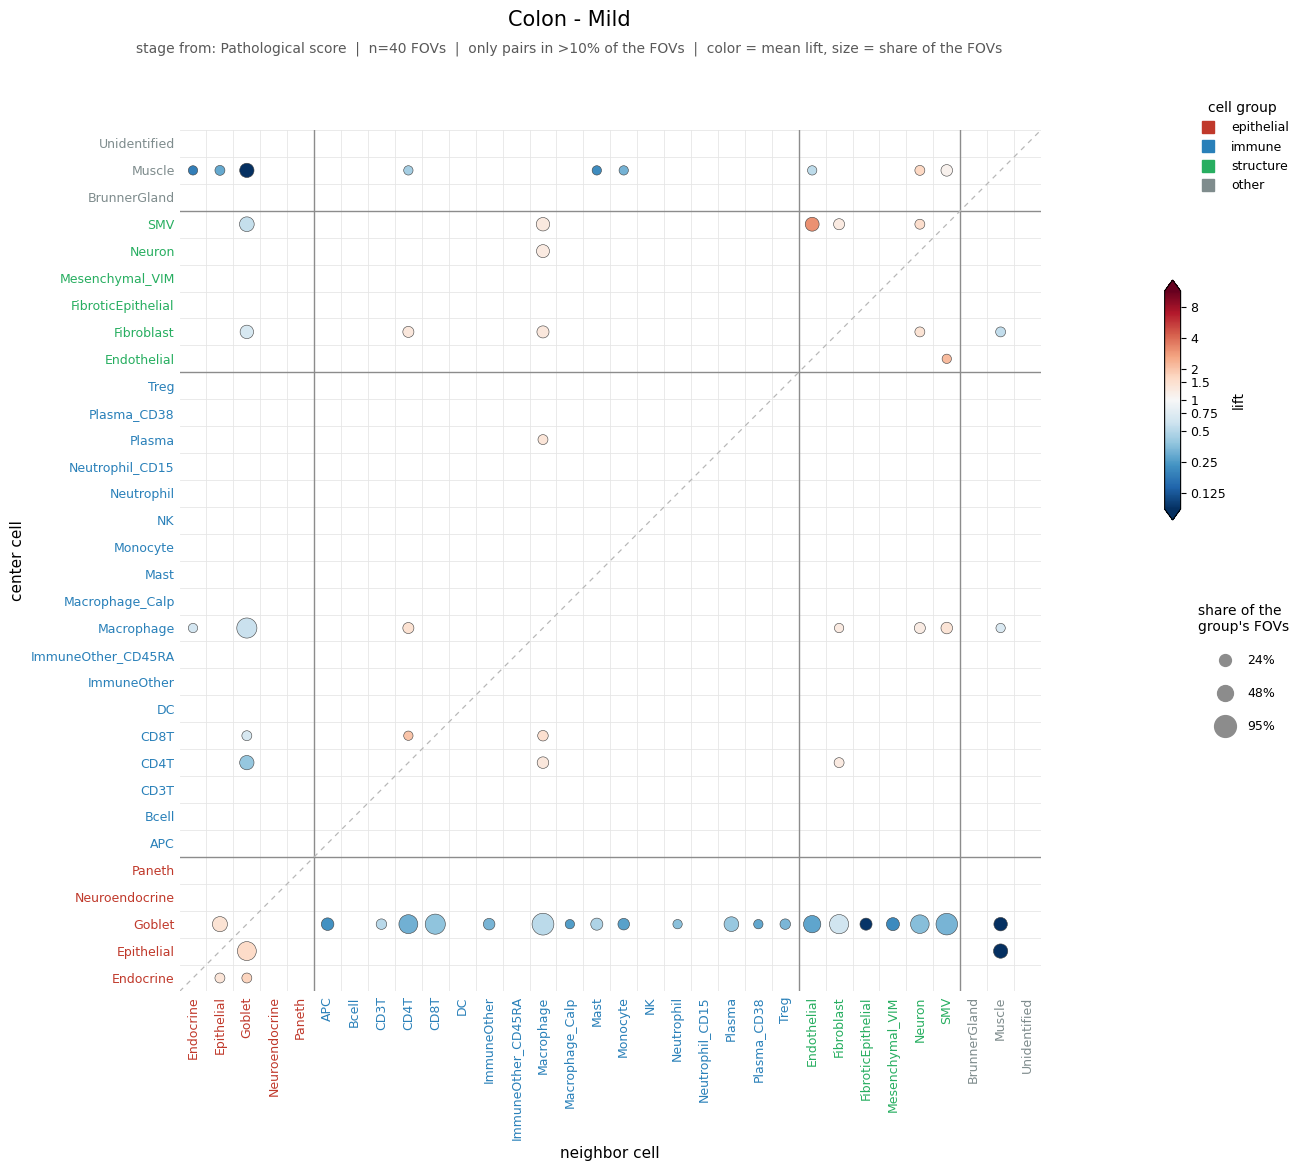

In [21]:
show_group('Colon', 'Mild')


Colon - Severe: 158 of 218 pairs dropped, in 10% or less of the FOVs (32)


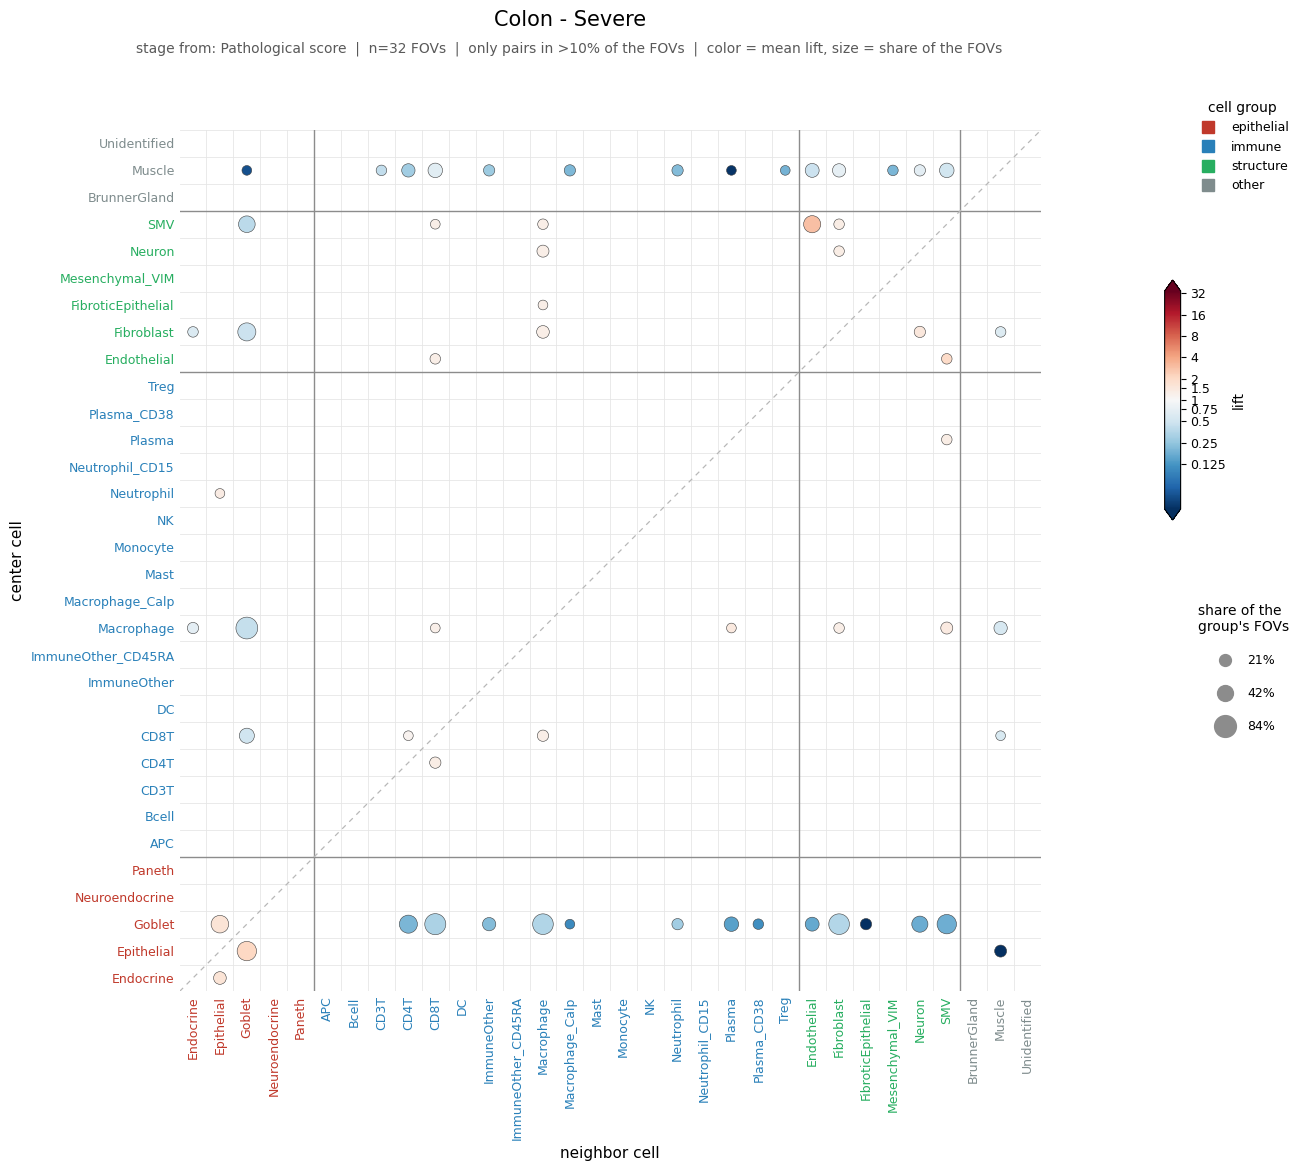

In [22]:
show_group('Colon', 'Severe')


Colon - Control: 90 of 183 pairs dropped, in 10% or less of the FOVs (25)
Colon - Mild: 136 of 196 pairs dropped, in 10% or less of the FOVs (40)
Colon - Severe: 158 of 218 pairs dropped, in 10% or less of the FOVs (32)
Duodenum - Control: 147 of 196 pairs dropped, in 10% or less of the FOVs (31)
Duodenum - Mild: 298 of 382 pairs dropped, in 10% or less of the FOVs (103)
Duodenum - Severe: 234 of 307 pairs dropped, in 10% or less of the FOVs (36)


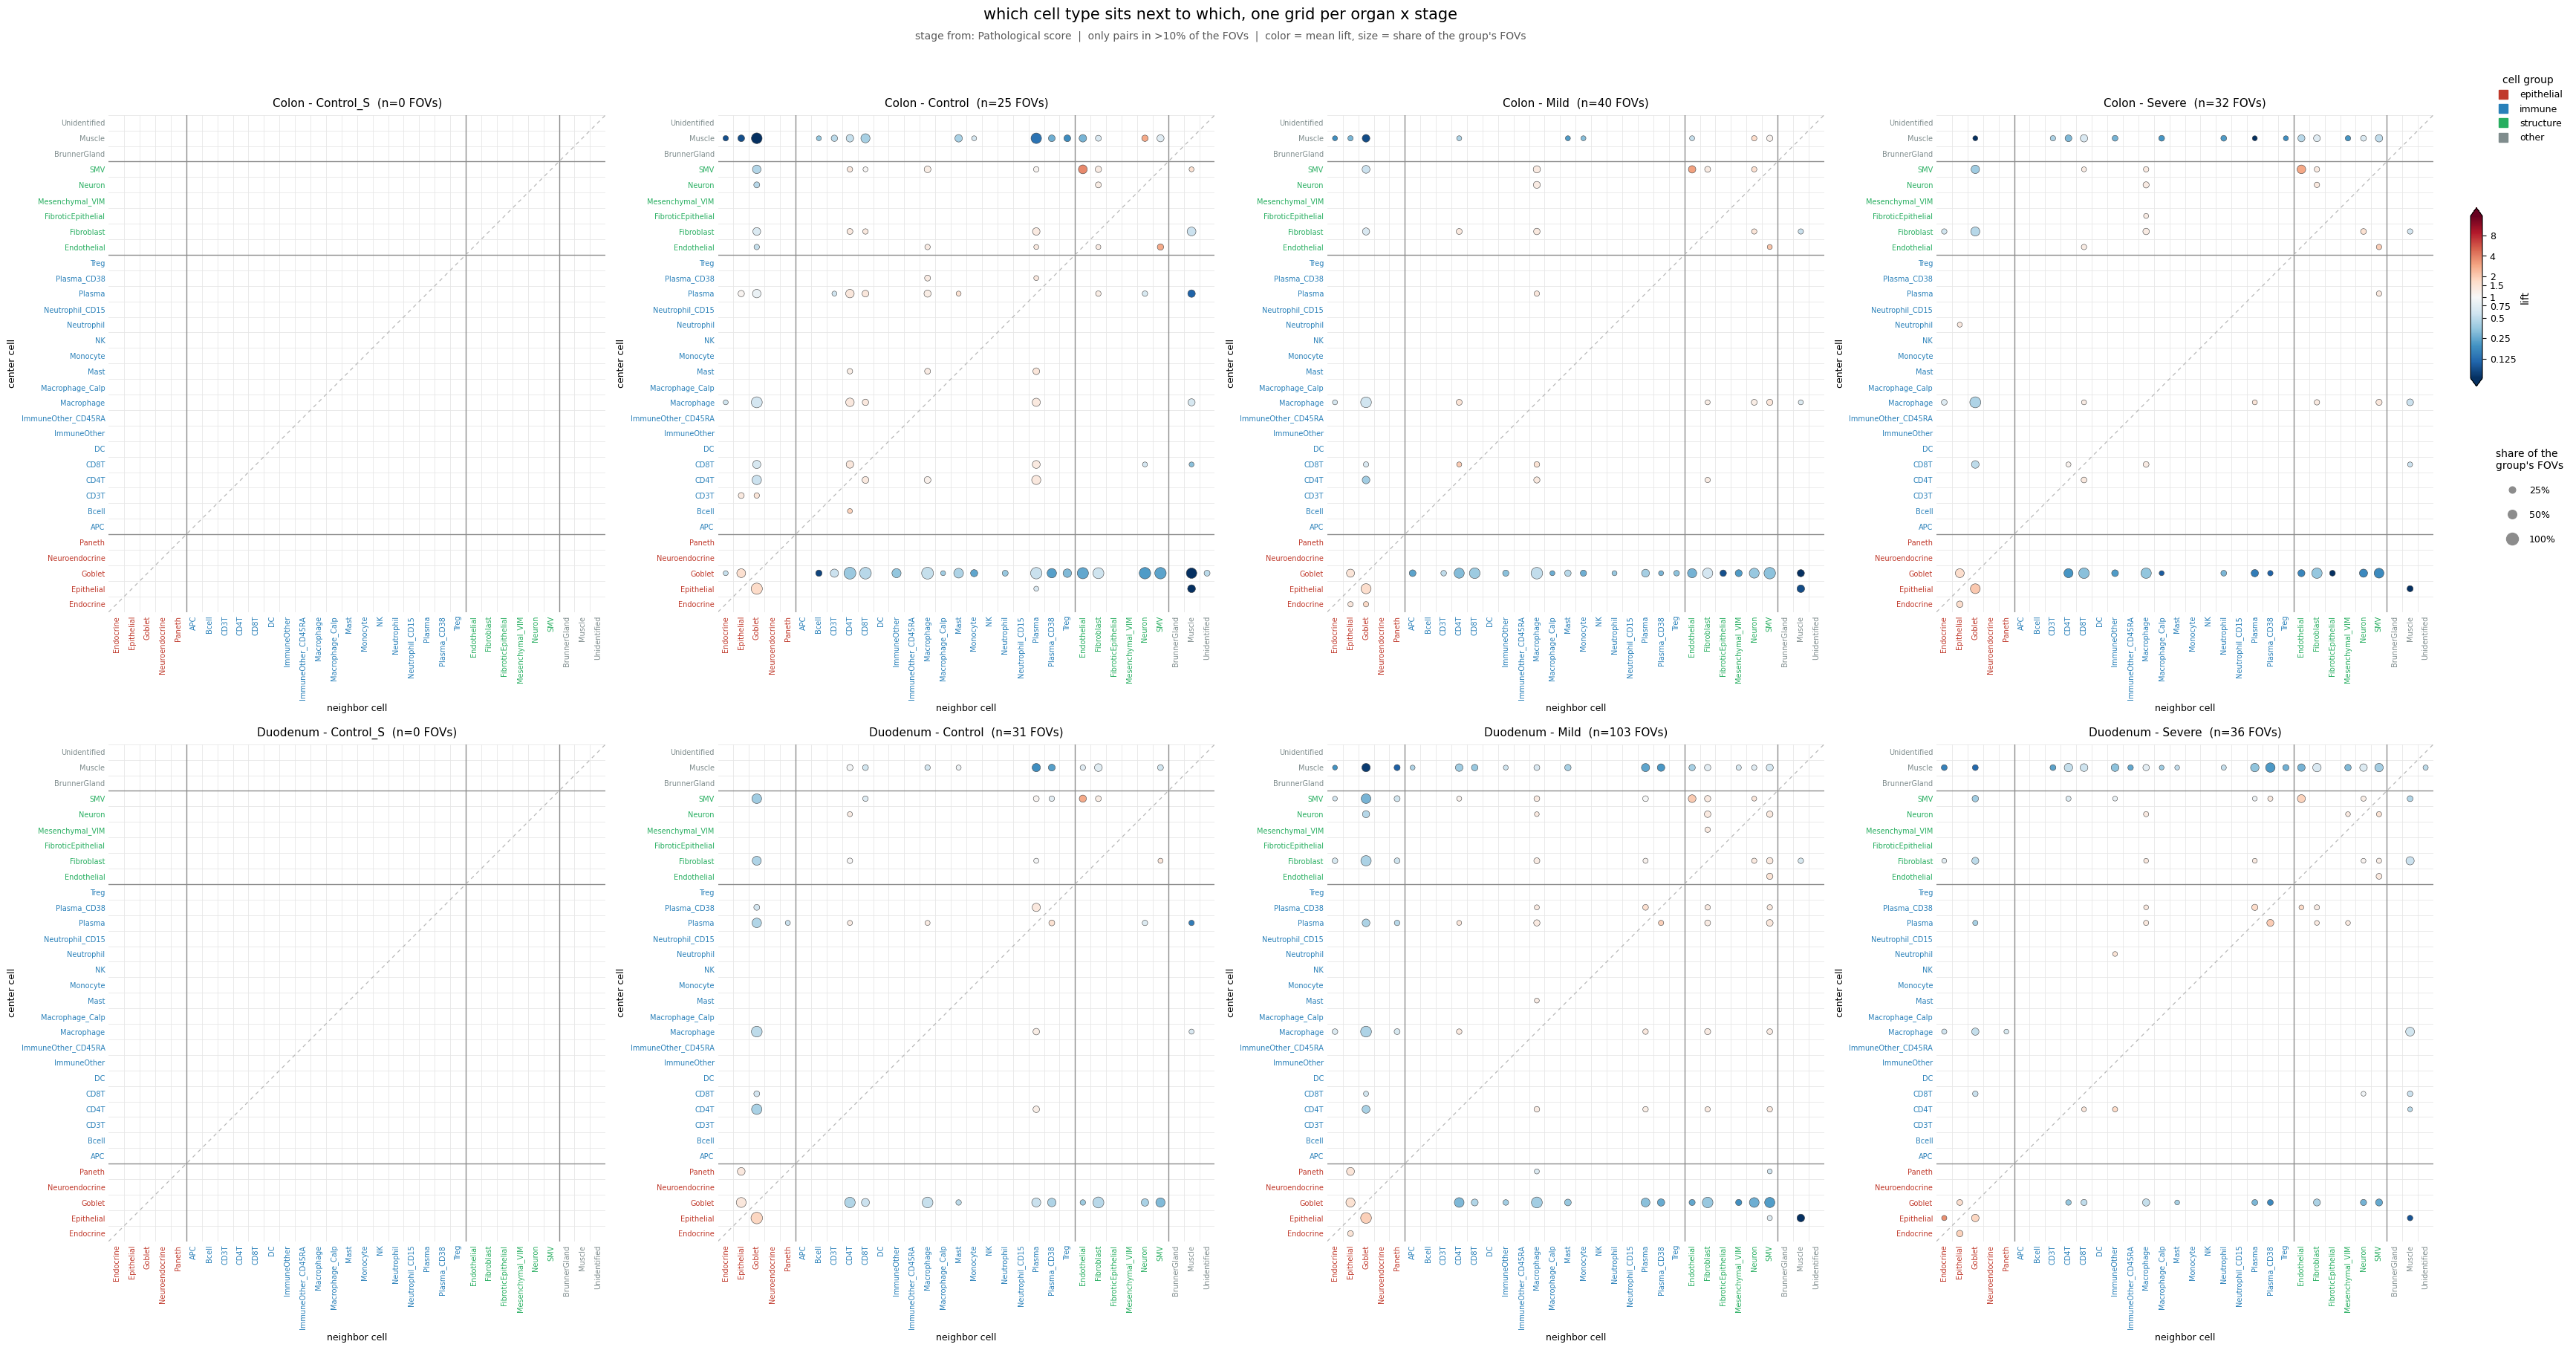

In [23]:
show_group_matrices()


Colon - Control: 90 of 183 pairs dropped, in 10% or less of the FOVs (25)
Colon - Mild: 66 of 133 pairs dropped, in 10% or less of the FOVs (18)
Colon - Severe: 185 of 257 pairs dropped, in 10% or less of the FOVs (54)
Duodenum - Control: 147 of 196 pairs dropped, in 10% or less of the FOVs (31)
Duodenum - Mild: 295 of 383 pairs dropped, in 10% or less of the FOVs (98)
Duodenum - Severe: 233 of 309 pairs dropped, in 10% or less of the FOVs (41)


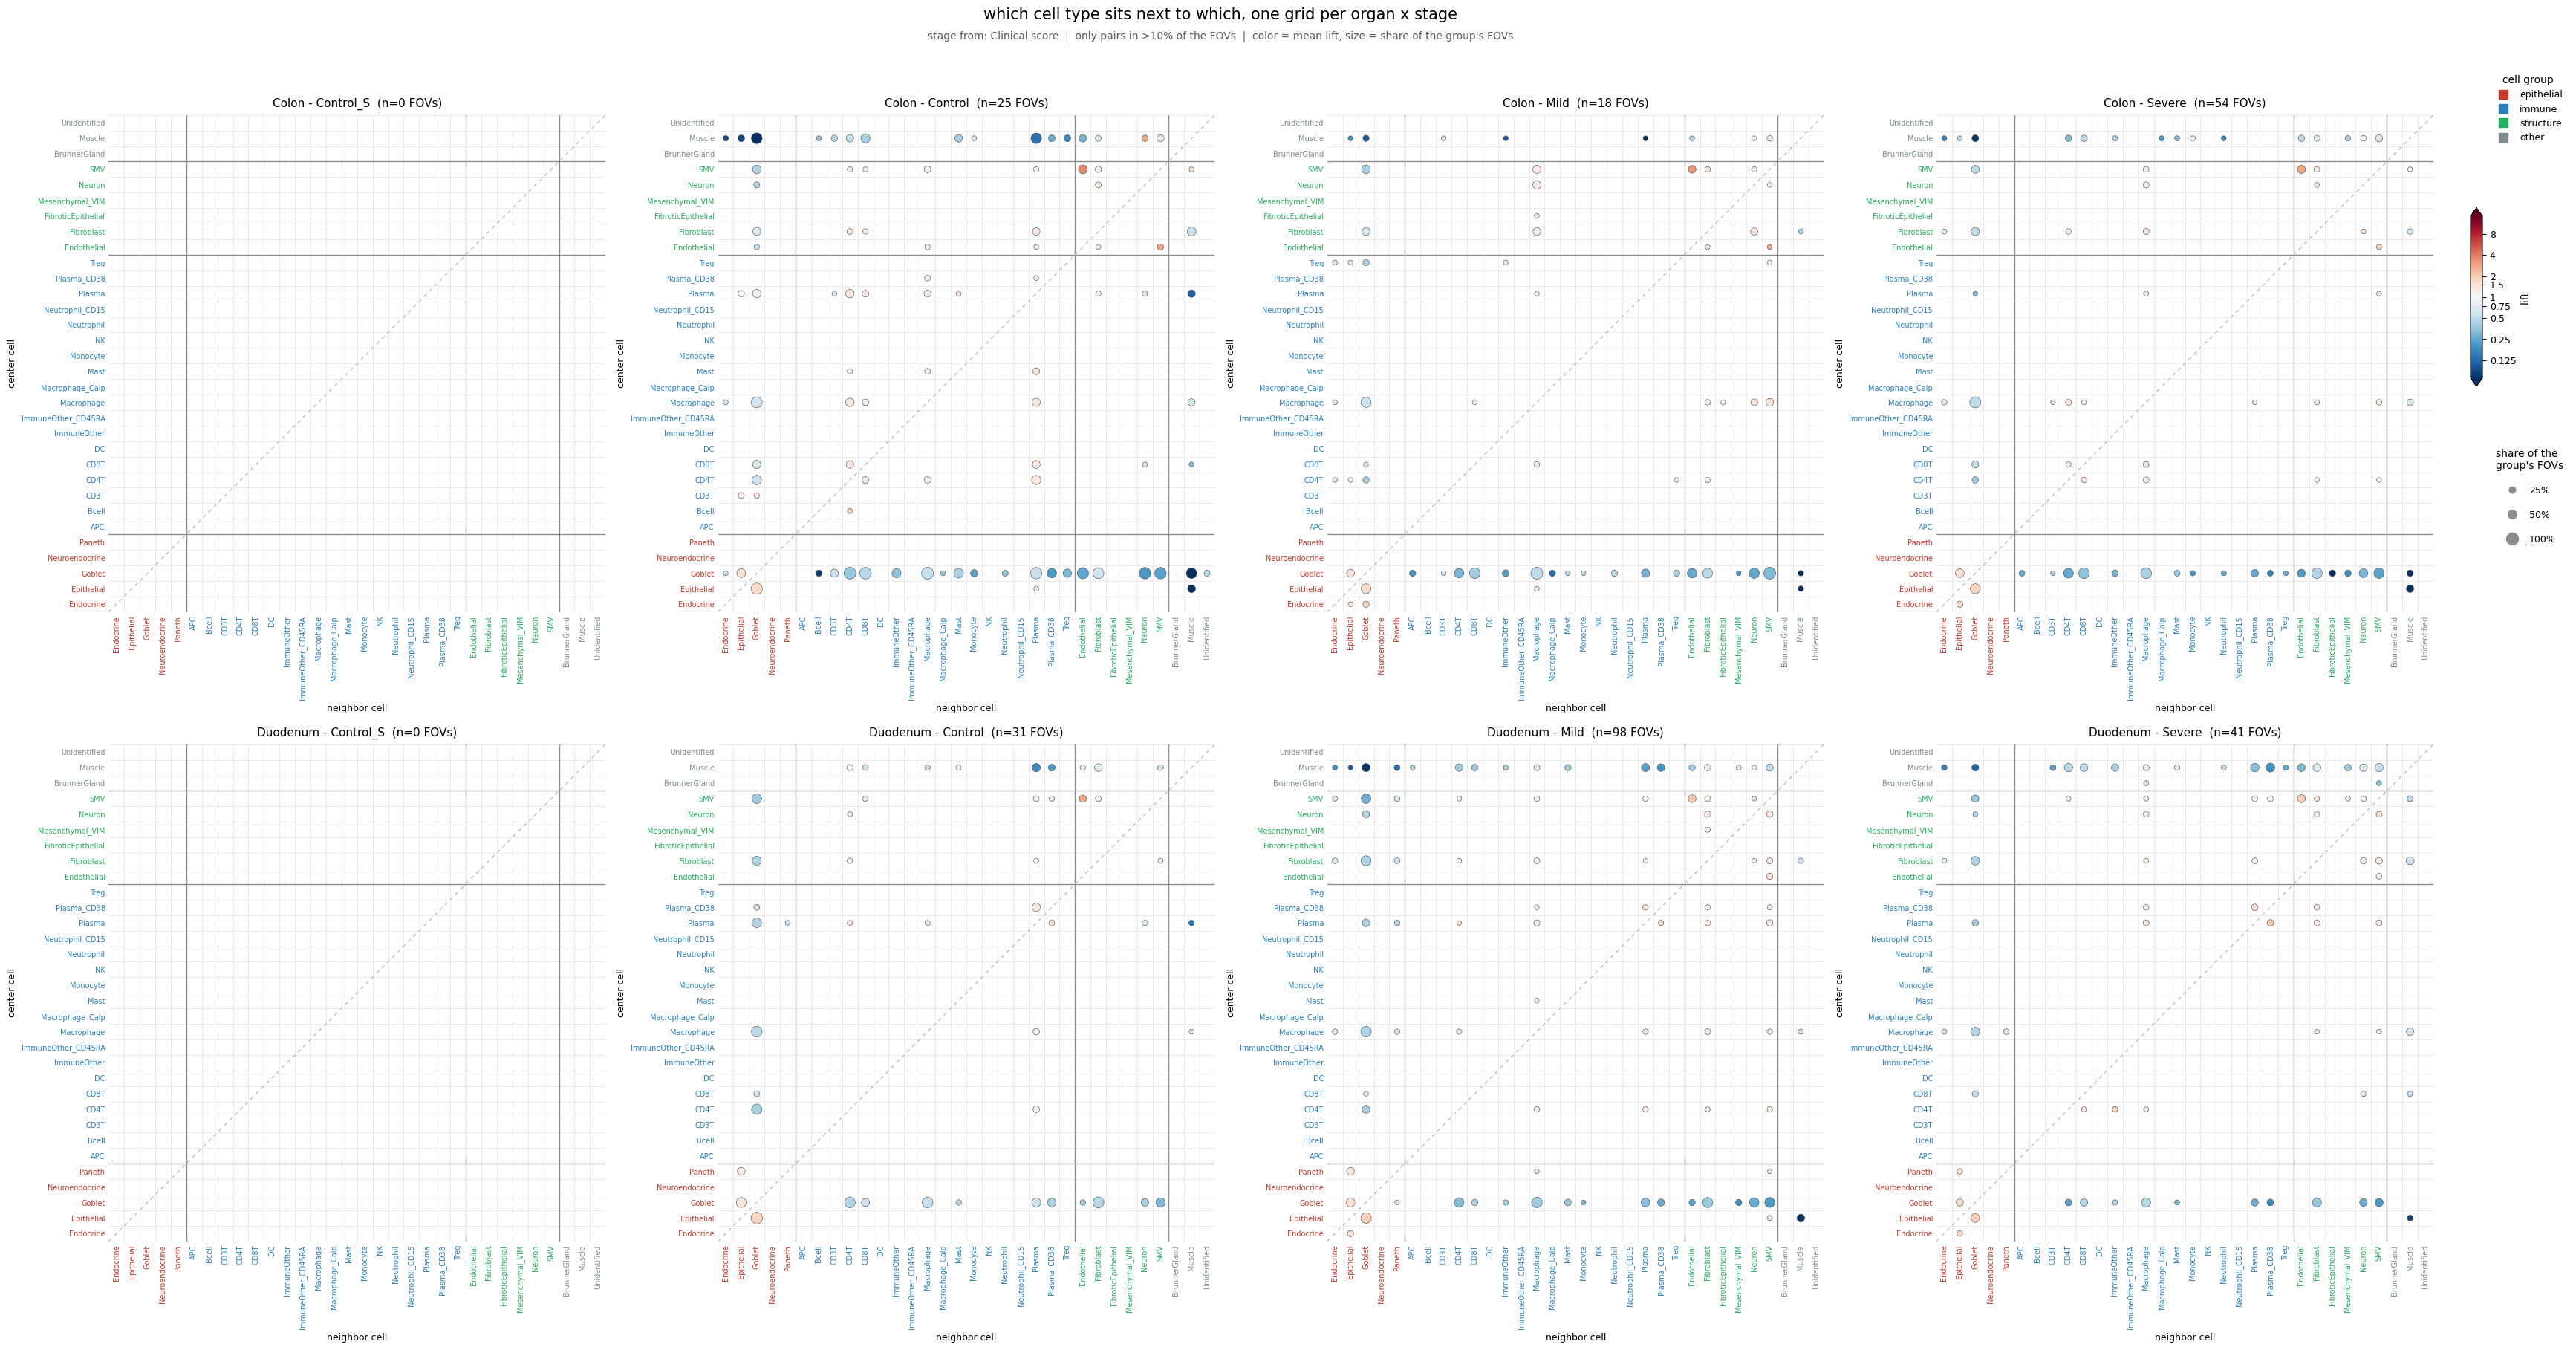

Colon - Control: 0 of 183 pairs dropped, in 10% or less of the patients (4)
Colon - Mild: 78 of 196 pairs dropped, in 10% or less of the patients (12)
Colon - Severe: 0 of 218 pairs dropped, in 10% or less of the patients (7)
Duodenum - Control: 76 of 196 pairs dropped, in 10% or less of the patients (10)
Duodenum - Mild: 220 of 382 pairs dropped, in 10% or less of the patients (30)
Duodenum - Severe: 0 of 307 pairs dropped, in 10% or less of the patients (9)


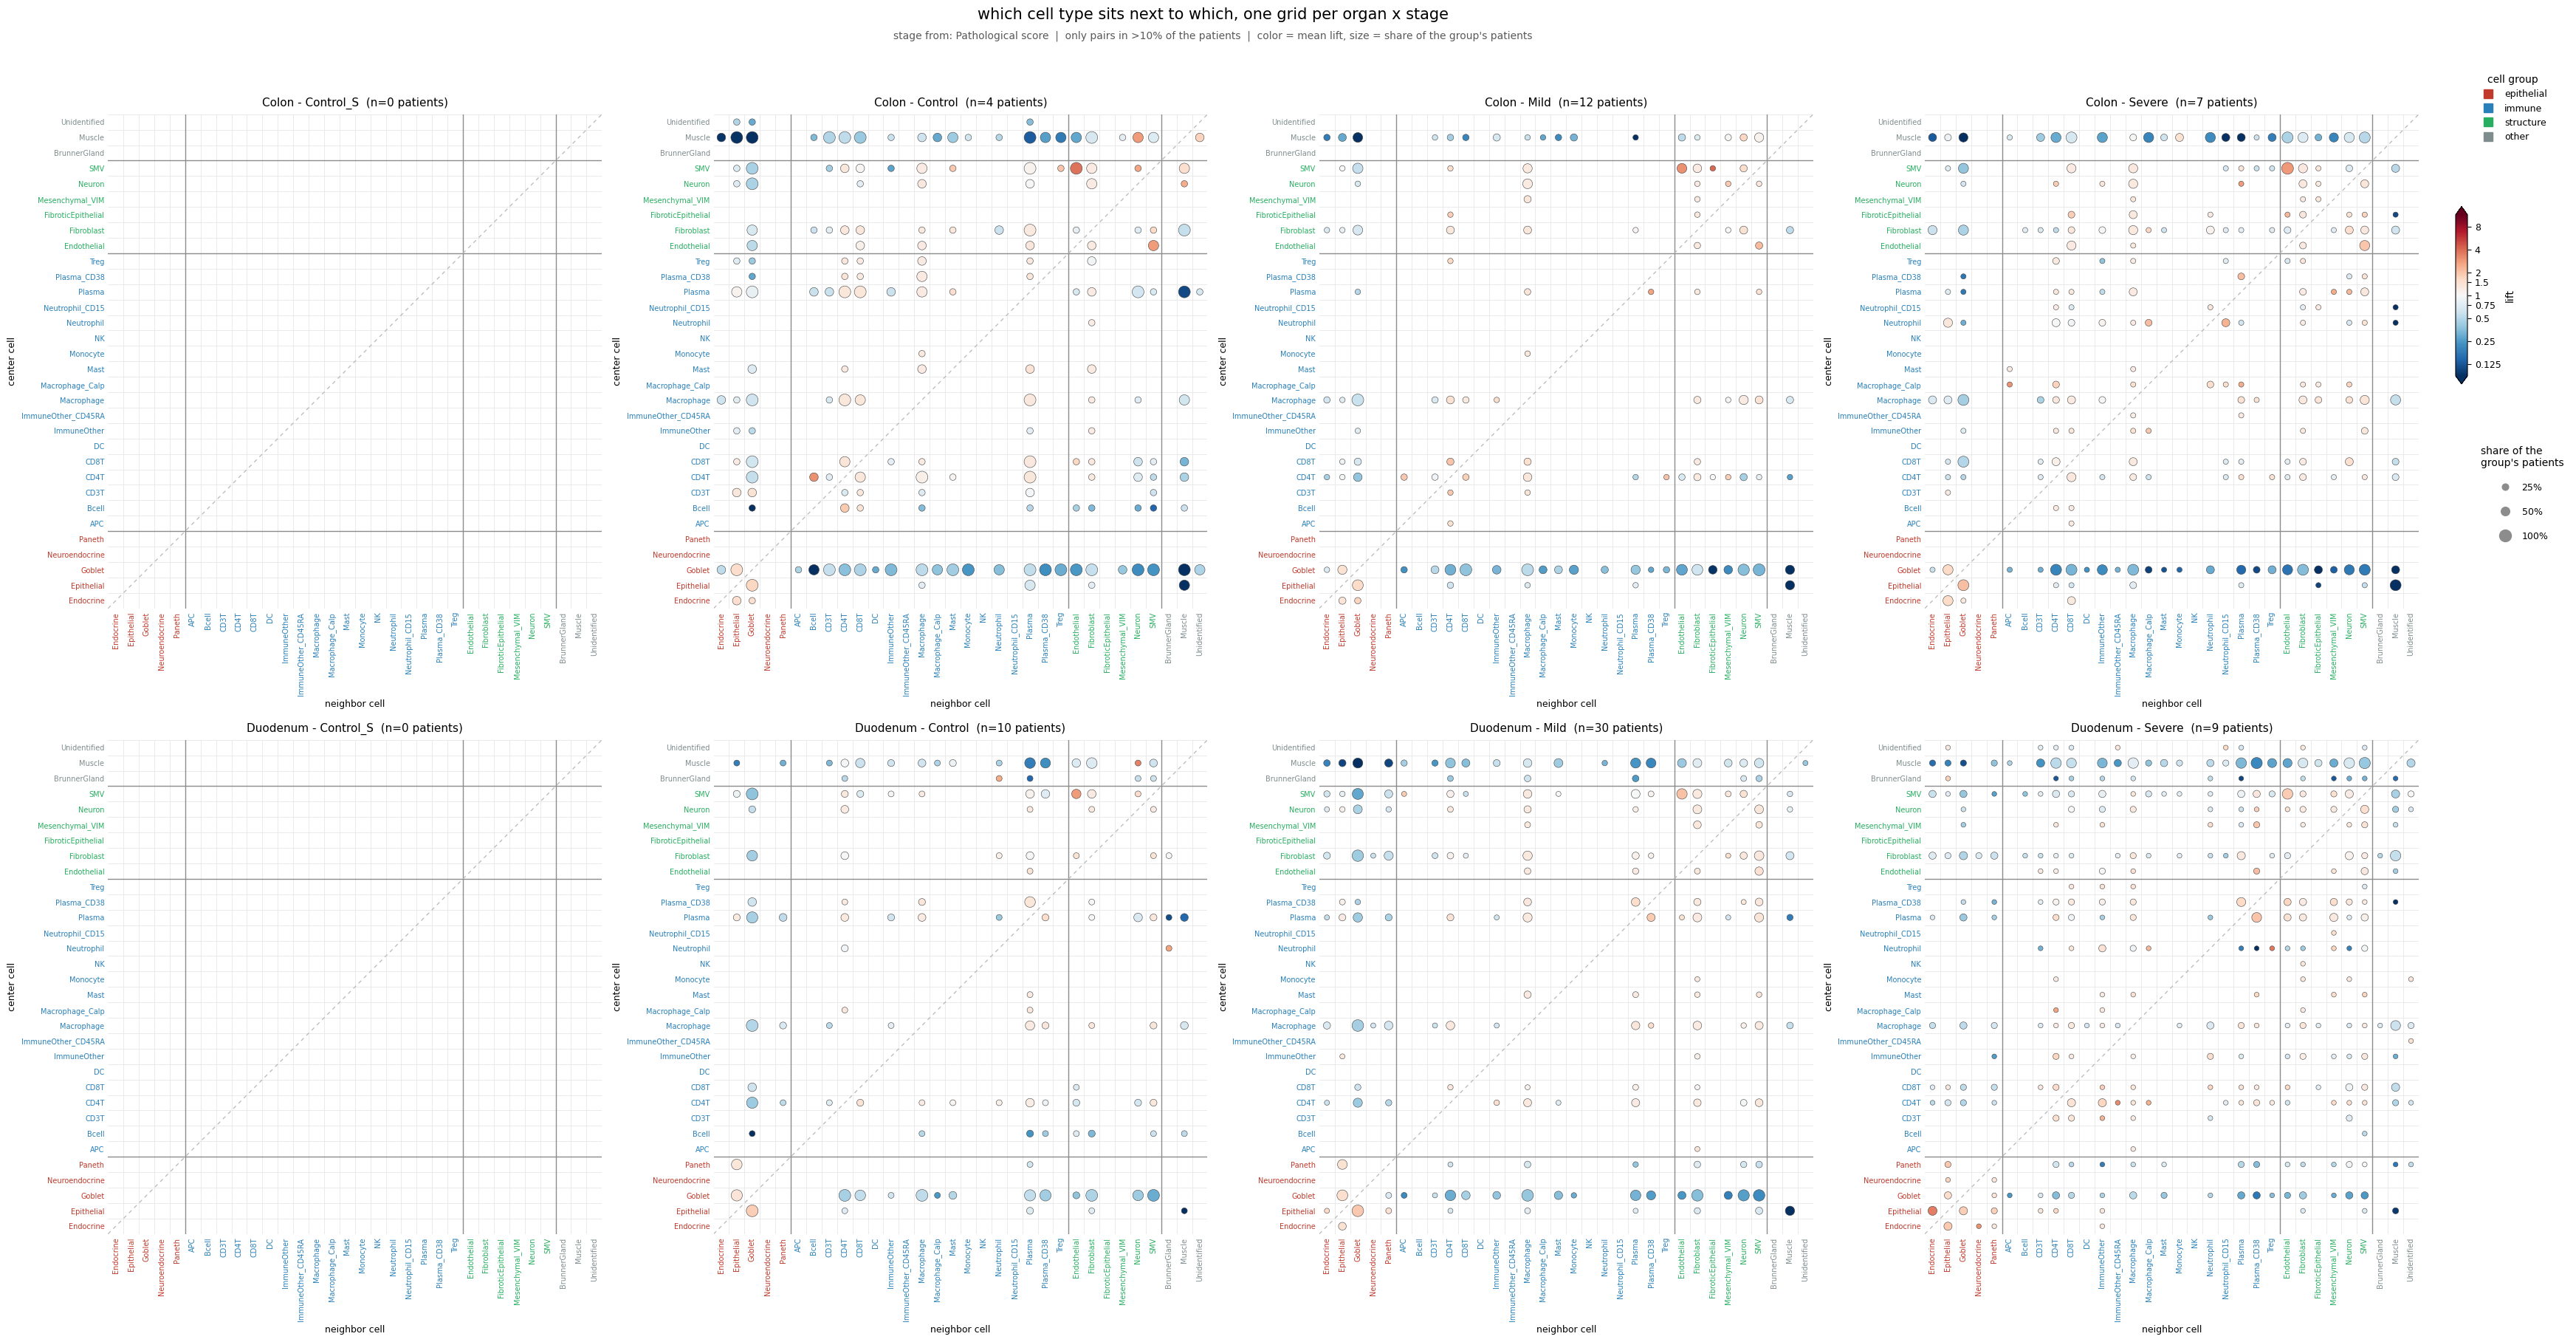

In [24]:
# The same panel against the clinical score.
show_group_matrices(score_col='Clinical score')

# ... and sized by the share of patients rather than of FOVs.
show_group_matrices(unit_col='PatientID')
